### Applying Unsupervised Learning for Variable Star Clustering Pipeline

In this notebook, we will be applying our full pipeline for unsupervised machine learning & clustering to UNLABELED data (candidate variables) from DP1 within the Fornax Region. We will applying the same methodology as we did with the labeled data in the notebook 'FSODO_pipeline_labeled.ipynb'

### Necessary Imports

In [1]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import astropy.units as units
import csv
import pandas as pd
import numpy as np

# for viz
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
import seaborn as sns

# sklearn imports
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# lsst pipelines
from lsst.rsp import get_tap_service

In [2]:
# get an instance of the TAP service and assert that it exists
service = get_tap_service("tap")
assert service is not None

pd.reset_option('display.max_rows')
pd.set_option('display.max_columns', None)

### Define Methods Used for Data Aggregation and Conversion (with data from ForcedSourceOnDiaObject)

In [3]:
# define methods for data collection and preprocessing
def fluxToABMagnitude(flux):
    return (-2.5 * np.log10(flux)) + 31.4

def fluxToDifferenceMagnitude(flux):
    return (-2.5 * np.log10(flux))

def getMagnitudeError(flux, flux_err):
    return (2.5 * np.log10(1 + (flux_err / flux)))

def getWeightedMean(mags, mag_errors):
    weights = 1 / (mag_errors**2)
    weighted_mean = np.sum(mags * weights) / np.sum(weights)

    return weighted_mean

### Retrieve set of candidate or likely variable stars

Thresholds We are Filtering By to retrieve 'Candidate' Variable Stars
1. r_psfFluxNData > 3
2. i_psfFluxNData > 3
3. r_psfFluxStetsonJ > 2
4. r_psfFluxChi2_red > 2

In [4]:
query = f"""SELECT diaObjectId, ra, dec, nDiaSources, i_psfFluxNdata, r_psfFluxNdata, r_psfFluxStetsonJ, i_psfFluxStetsonJ, r_psfFluxChi2, i_psfFluxChi2,
        (r_psfFluxChi2 / (r_psfFluxNdata - 1)) AS r_psfFluxChi2_red,
        (i_psfFluxChi2 / (i_psfFluxNdata - 1)) AS i_psfFluxChi2_red
        FROM dp1.DiaObject
        WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 40.00, -34.45, 1)) = 1
        AND r_psfFluxNdata > 3
        AND i_psfFluxNdata > 3
        AND r_psfFluxStetsonJ > 2
        AND (r_psfFluxChi2 / (r_psfFluxNdata - 1)) > 2
        ORDER BY diaObjectId ASC
        """

job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
catalog = job.fetch_result().to_table().to_pandas() #get results -> turn into table -> turn table into pandas dataframe
print(str(len(catalog)))

Job phase is COMPLETED
3420


In [5]:
catalog

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red
0,604061930134437889,40.240730,-34.791263,16,4.0,12.0,6.533758,24.194830,665.762024,2082.129883,60.523848,694.042806
1,604061930134437890,40.235645,-34.806367,13,4.0,9.0,5.623579,17.113869,386.424988,1036.430054,48.303112,345.477539
2,604061998853914625,40.015143,-34.831573,13,5.0,8.0,7.872383,8.982519,616.070984,981.286011,88.010114,245.321594
3,604061998853914626,40.045684,-34.836700,12,5.0,7.0,5.620213,18.668195,321.329010,1863.709961,53.554759,465.928345
4,604061998853914628,40.029396,-34.810658,16,8.0,8.0,6.525418,16.089444,607.476990,2906.179932,86.782453,415.168457
...,...,...,...,...,...,...,...,...,...,...,...,...
3415,605447864541249611,39.883685,-34.051543,15,4.0,10.0,20.520259,31.318724,4831.700195,3557.610107,536.856011,1185.870768
3416,605447864541249614,39.898670,-34.043917,10,4.0,6.0,6.653677,12.008664,328.299011,640.103027,65.659760,213.367533
3417,605447864541249617,39.925197,-34.096314,12,5.0,7.0,6.215166,4.828075,264.377014,130.408997,44.062780,32.602257
3418,605447864541249621,39.966921,-34.084119,13,4.0,9.0,2.802083,4.384077,152.283997,108.302002,19.035492,36.100789


In [6]:
# load csv of classified variable stars
path = os.getcwd()
v_star_catalog_path = os.path.join(path, 'variable_star_all_feat.csv')

v_star_catalog = pd.read_csv(v_star_catalog_path)

pd.reset_option('display.max_rows')
pd.set_option('display.max_columns', None)
v_star_catalog

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,47,RRLyrae,RR*,True,NaN,6659.355957,NaN,NaN,6659.355957,NaN,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54098.902344,NaN,NaN,NaN,NaN,NaN,19.567029,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae,RR*,True,2142.085449,NaN,NaN,2142.085449,NaN,NaN,2142.085449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39428.195312,NaN,NaN,NaN,NaN,NaN,19.910483,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,NaN,254.26800,NaN,NaN,15.224242,0.0,NaN,5219.070000,1.0,NaN,2.0,3,47,RRLyrae,RR*,True,-2534.255371,NaN,4585.559766,-2534.255371,NaN,-111.599121,-2534.255371,NaN,-4808.757520,NaN,NaN,-868.516082,NaN,NaN,-8.683926e+02,NaN,NaN,NaN,29299.523438,NaN,47978.964844,NaN,NaN,8083.117155,20.232849,NaN,19.697373,NaN,NaN,0.535476,0.0,NaN,NaN,inf,NaN,254.268000,NaN,NaN,-959.090718,NaN,0.0,0.161275,NaN,NaN,0.168472,NaN,NaN,NaN,19.015177
3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,0.000000e+00,NaN,0.00000,NaN,NaN,NaN,0.0,NaN,0.000000,1.0,NaN,1.0,2,47,RRLyrae,RR*,True,7049.521484,NaN,2416.182129,7049.521484,NaN,2416.182129,7049.521484,NaN,2416.182129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52186.820312,NaN,50817.039062,NaN,NaN,NaN,19.606098,NaN,19.634977,NaN,NaN,-0.028879,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,19.671768
4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,36.384200,522.44600,NaN,4.992266,12.702006,0.0,1478.850000,4499.990000,1.0,2.0,4.0,7,47,RRLyrae,RR*,True,2554.464600,-5671.762036,4388.073193,2554.464600,-7002.723389,-603.957764,2554.464600,-8333.684741,-5389.621338,NaN,-589.070678,759.578197,NaN,-589.170293,1.353681e+06,NaN,NaN,0.01399,33321.984375,42114.656250,45757.542969,NaN,691.970277,5163.227435,20.093173,19.838917,19.748843,0.254256,0.090074,0.344330,0.0,2661.922705,-282.140698,NaN,36.384200,174.148667,NaN,-0.308456,-6.606807,0.052061,0.0,0.145805,NaN,0.016431,0.112839,19.474029,19.100303,19.264337,19.310167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,604072100616995077,40.407272,-34.255539,NaN,-2344.862061,1329.692993,NaN,299.926727,37.739925,NaN,9.630550,0.02401,NaN,0.422049,-0

In [7]:
# check for value counts in fornax as well as number of each type
display(v_star_catalog['Region'].value_counts())
print()
display(v_star_catalog['Class'].value_counts())

Region
Fornax     600
47         104
Seagull     34
LGLF         8
LELF         4
EDFS         1
Name: count, dtype: int64

Class
RRLyrae    520
LPV        212
Cepheid     19
Name: count, dtype: int64

In [286]:
((v_star_catalog['Region'] == 'Fornax') & (v_star_catalog['Class'] == 'RRLyrae')).sum()

np.int64(443)

In [8]:
# merge any matching stars from our labeled variable star catalog
catalog = catalog.merge(v_star_catalog[['diaObjectId', 'Class']], on='diaObjectId', how='left')

In [9]:
catalog

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red,Class
0,604061930134437889,40.240730,-34.791263,16,4.0,12.0,6.533758,24.194830,665.762024,2082.129883,60.523848,694.042806,NaN
1,604061930134437890,40.235645,-34.806367,13,4.0,9.0,5.623579,17.113869,386.424988,1036.430054,48.303112,345.477539,NaN
2,604061998853914625,40.015143,-34.831573,13,5.0,8.0,7.872383,8.982519,616.070984,981.286011,88.010114,245.321594,NaN
3,604061998853914626,40.045684,-34.836700,12,5.0,7.0,5.620213,18.668195,321.329010,1863.709961,53.554759,465.928345,NaN
4,604061998853914628,40.029396,-34.810658,16,8.0,8.0,6.525418,16.089444,607.476990,2906.179932,86.782453,415.168457,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3415,605447864541249611,39.883685,-34.051543,15,4.0,10.0,20.520259,31.318724,4831.700195,3557.610107,536.856011,1185.870768,NaN
3416,605447864541249614,39.898670,-34.043917,10,4.0,6.0,6.653677,12.008664,328.299011,640.103027,65.659760,213.367533,NaN
3417,605447864541249617,39.925197,-34.096314,12,5.0,7.0,6.215166,4.828075,264.377014,130.408997,44.062780,32.602257,NaN
3418,605447864541249621,39.966921,-34.084119,13,4.0,9.0,2.802083,4.384077,152.283997,108.302002,19.035492,36.100789,NaN


In [10]:
catalog['Class'].value_counts() # 181 were mapped to objects in our catalog (likely due to our filtering and limited observations) 

Class
LPV        114
RRLyrae     58
Cepheid      9
Name: count, dtype: int64

In [11]:
# set all classes which are nan to 'Unlabeled'
catalog['Class'] = catalog['Class'].fillna('Unlabeled')

In [12]:
id_list = catalog['diaObjectId'].tolist()
id_list_str = ','.join(str(x) for x in id_list)
len(id_list)

3420

### Retrieve FSODO information for forced photometry at location of all of objects in catalog

In [13]:
# we want to filter out any flagged photometry measurements, those in other filter bands (u, z, y) and those which have disproportionate error relative to flux
query = f"""SELECT fsodo.diaObjectId, fsodo.band, fsodo.coord_ra, fsodo.coord_dec, fsodo.psfFlux, fsodo.psfFluxErr,
        fsodo.invalidPsfFlag, fsodo.psfFlux_flag, fsodo.pixelFlags_saturated, fsodo.pixelFlags_cr, fsodo.pixelFlags_bad, fsodo.pixelFlags_interpolated, fsodo.pixelFlags_suspect, fsodo.pixelFlags_edge, fsodo.pixelFlags_nodata,
        vis.expMidptMJD
        FROM dp1.ForcedSourceOnDiaObject AS fsodo
        JOIN dp1.Visit as vis 
        ON vis.visit = fsodo.visit
        WHERE fsodo.diaObjectId IN ({id_list_str})
        AND fsodo.band IS NOT NULL
        AND fsodo.invalidPsfFlag = 0
        AND fsodo.psfFlux_flag = 0
        AND fsodo.pixelFlags_saturated = 0
        AND fsodo.pixelFlags_cr = 0
        AND fsodo.pixelFlags_bad = 0
        AND fsodo.pixelFlags_interpolated = 0
        AND fsodo.pixelFlags_suspect = 0
        AND fsodo.pixelFlags_edge = 0
        AND fsodo.pixelFlags_nodata = 0
        AND fsodo.band IN ('g', 'r', 'i')
        AND fsodo.psfFluxErr < 0.1 * fsodo.psfFlux
        ORDER BY fsodo.diaObjectId ASC
        """


job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
catalog_FSODO = job.fetch_result().to_table().to_pandas() #get results -> turn into table -> turn table into pandas dataframe
print(str(len(catalog_FSODO)))

Job phase is COMPLETED
109471


In [14]:
catalog_FSODO

,diaObjectId,band,coord_ra,coord_dec,psfFlux,psfFluxErr,invalidPsfFlag,psfFlux_flag,pixelFlags_saturated,pixelFlags_cr,pixelFlags_bad,pixelFlags_interpolated,pixelFlags_suspect,pixelFlags_edge,pixelFlags_nodata,expMidptMJD
0,604061930134437889,r,40.240730,-34.791263,215943.000000,460.678986,False,False,False,False,False,False,False,False,False,60639.254291
1,604061930134437889,g,40.240730,-34.791263,79724.898438,292.187012,False,False,False,False,False,False,False,False,False,60650.182431
2,604061930134437889,r,40.240730,-34.791263,218957.000000,465.355011,False,False,False,False,False,False,False,False,False,60639.248370
3,604061930134437889,r,40.240730,-34.791263,217085.000000,459.931000,False,False,False,False,False,False,False,False,False,60639.251930
4,604061930134437889,i,40.240730,-34.791263,345934.000000,660.534973,False,False,False,False,False,False,False,False,False,60650.183901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109466,605447864541249724,r,39.954659,-34.131313,121366.000000,344.838989,False,False,False,False,False,False,False,False,False,60639.249554
109467,605447864541249724,g,39.954659,-34.131313,48716.000000,240.820007,False,False,False,False,False,False,False,False,False,60650.182017
109468,605447864541249724,i,39.954659,-34.131313,160500.000000,471.334015,False,False,False,False,False,False,False,False,False,60650.184726
109469,605447864541249724,r,39.954659,-34.131313,119175.000000,344.787994,False,False,False,False,False,False,False,False,False,60639.273603


In [15]:
catalog_FSODO['psfFluxMag'] = fluxToABMagnitude(catalog_FSODO['psfFlux']) # convert each raw psfFlux value to magnitude
catalog_FSODO['psfFluxMagErr'] = getMagnitudeError(catalog_FSODO['psfFlux'], catalog_FSODO['psfFluxErr']) # convert psfFluxErr to mag error

In [16]:
catalog_FSODO

,diaObjectId,band,coord_ra,coord_dec,psfFlux,psfFluxErr,invalidPsfFlag,psfFlux_flag,pixelFlags_saturated,pixelFlags_cr,pixelFlags_bad,pixelFlags_interpolated,pixelFlags_suspect,pixelFlags_edge,pixelFlags_nodata,expMidptMJD,psfFluxMag,psfFluxMagErr
0,604061930134437889,r,40.240730,-34.791263,215943.000000,460.678986,False,False,False,False,False,False,False,False,False,60639.254291,18.064152,0.002314
1,604061930134437889,g,40.240730,-34.791263,79724.898438,292.187012,False,False,False,False,False,False,False,False,False,60650.182431,19.146015,0.003972
2,604061930134437889,r,40.240730,-34.791263,218957.000000,465.355011,False,False,False,False,False,False,False,False,False,60639.248370,18.049103,0.002305
3,604061930134437889,r,40.240730,-34.791263,217085.000000,459.931000,False,False,False,False,False,False,False,False,False,60639.251930,18.058426,0.002298
4,604061930134437889,i,40.240730,-34.791263,345934.000000,660.534973,False,False,False,False,False,False,False,False,False,60650.183901,17.552517,0.002071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109466,605447864541249724,r,39.954659,-34.131313,121366.000000,344.838989,False,False,False,False,False,False,False,False,False,60639.249554,18.689756,0.003081
109467,605447864541249724,g,39.954659,-34.131313,48716.000000,240.820007,False,False,False,False,False,False,False,False,False,60650.182017,19.680820,0.005354
109468,605447864541249724,i,39.954659,-34.131313,160500.000000,471.334015,False,False,False,False,False,False,False,False,False,60650.184726,18.386311,0.003184
109469,605447864541249724,r,39.954659,-34.131313,119175.000000,344.787994,False,False,False,False,False,False,False,False,False,60639.273603,18.709536,0.003137


In [18]:
# group each set of photometry measurements by object & band and then sort each group / set by time of observation
# we are sorting chronologically to calculate 'max-slope' of each group below
catalog_FSODO_sorted = catalog_FSODO.groupby(['diaObjectId', 'band'], group_keys=False).apply(lambda group: group.sort_values('expMidptMJD'))

/tmp/ipykernel_644/3251222176.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catalog_FSODO_sorted = catalog_FSODO.groupby(['diaObjectId', 'band'], group_keys=False).apply(lambda group: group.sort_values('expMidptMJD'))


In [19]:
# after grouping, calculate a weighted mean of each magnitude (takes into account error as 'weight') for each object in each band
weightedMean_df = catalog_FSODO_sorted.groupby(['diaObjectId', 'band'])[['psfFluxMag', 'psfFluxMagErr']].apply(lambda group: pd.Series({'weighted_mean_mag': getWeightedMean(group['psfFluxMag'], group['psfFluxMagErr'])})).reset_index()

In [20]:
weightedMean_df

,diaObjectId,band,weighted_mean_mag
0,604061930134437889,g,19.146015
1,604061930134437889,i,17.573280
2,604061930134437889,r,18.055819
3,604061930134437890,g,19.513411
4,604061930134437890,i,18.348675
...,...,...,...
10201,605447864541249621,i,17.793661
10202,605447864541249621,r,18.265190
10203,605447864541249724,g,19.666067
10204,605447864541249724,i,18.360182


In [21]:
# perform same groupby operation to retrieve mean psfFlux and psfFluxErr
catalog_FSODO_temp = catalog_FSODO.groupby(['diaObjectId', 'band'])[['psfFlux', 'psfFluxErr']].mean().reset_index()

In [22]:
catalog_FSODO_temp.rename(columns={'psfFlux':'psfFluxMean'}, inplace=True)

In [23]:
catalog_FSODO_temp = pd.merge(catalog_FSODO_temp, weightedMean_df, on=['diaObjectId', 'band'], how='inner') # merge these calculations with the weighted mean calculations

In [24]:
catalog_FSODO_temp

,diaObjectId,band,psfFluxMean,psfFluxErr,weighted_mean_mag
0,604061930134437889,g,79724.898438,292.187012,19.146015
1,604061930134437889,i,339437.750000,645.002502,17.573280
2,604061930134437889,r,217605.578125,460.989899,18.055819
3,604061930134437890,g,56837.601562,254.158997,19.513411
4,604061930134437890,i,166336.250000,468.244995,18.348675
...,...,...,...,...,...
10201,605447864541249621,i,277059.500000,583.450012,17.793661
10202,605447864541249621,r,179446.859375,415.877350,18.265190
10203,605447864541249724,g,49355.066406,239.706985,19.666067
10204,605447864541249724,i,164167.109375,462.604126,18.360182


In [25]:
catalog_FSODO_sorted

,diaObjectId,band,coord_ra,coord_dec,psfFlux,psfFluxErr,invalidPsfFlag,psfFlux_flag,pixelFlags_saturated,pixelFlags_cr,pixelFlags_bad,pixelFlags_interpolated,pixelFlags_suspect,pixelFlags_edge,pixelFlags_nodata,expMidptMJD,psfFluxMag,psfFluxMagErr
1,604061930134437889,g,40.240730,-34.791263,79724.898438,292.187012,False,False,False,False,False,False,False,False,False,60650.182431,19.146015,0.003972
10,604061930134437889,i,40.240730,-34.791263,334956.000000,633.706970,False,False,False,False,False,False,False,False,False,60639.270637,17.587530,0.002052
14,604061930134437889,i,40.240730,-34.791263,334581.000000,636.085999,False,False,False,False,False,False,False,False,False,60639.271225,17.588745,0.002062
4,604061930134437889,i,40.240730,-34.791263,345934.000000,660.534973,False,False,False,False,False,False,False,False,False,60650.183901,17.552517,0.002071
8,604061930134437889,i,40.240730,-34.791263,342280.000000,649.682007,False,False,False,False,False,False,False,False,False,60650.184310,17.564045,0.002059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109469,605447864541249724,r,39.954659,-34.131313,119175.000000,344.787994,False,False,False,False,False,False,False,False,False,60639.273603,18.709536,0.003137
109446,605447864541249724,r,39.954659,-34.131313,120159.000000,349.272003,False,False,False,False,False,False,False,False,False,60639.274200,18.700607,0.003151
109439,605447864541249724,r,39.954659,-34.131313,112126.000000,334.207001,False,False,False,False,False,False,False,False,False,60650.178297,18.775732,0.003231
109454,605447864541249724,r,39.954659,-34.131313,112453.000000,333.571991,False,False,False,False,False,False,False,False,False,60650.178708,18.772572,0.003216


In [26]:
# code to retrieve slope (delta psflux / delta time) for every pair of observations
prev_diaObjectId = -1
prev_band = ''
prev_psfFluxMag, prev_mjd = -1, -1
for index,row in catalog_FSODO_sorted.iterrows():
    if (row['diaObjectId'] == prev_diaObjectId) and (row['band'] == prev_band):
        catalog_FSODO_sorted.loc[index, 'slope'] = np.abs((row['psfFluxMag'] - prev_psfFluxMag) / (row['expMidptMJD'] - prev_mjd))
    else:
        catalog_FSODO_sorted.loc[index, 'slope'] = None

    prev_diaObjectId = row['diaObjectId']
    prev_band = row['band']
    prev_psfFluxMag = row['psfFluxMag']
    prev_mjd = row['expMidptMJD']

In [27]:
catalog_FSODO_sorted

,diaObjectId,band,coord_ra,coord_dec,psfFlux,psfFluxErr,invalidPsfFlag,psfFlux_flag,pixelFlags_saturated,pixelFlags_cr,pixelFlags_bad,pixelFlags_interpolated,pixelFlags_suspect,pixelFlags_edge,pixelFlags_nodata,expMidptMJD,psfFluxMag,psfFluxMagErr,slope
1,604061930134437889,g,40.240730,-34.791263,79724.898438,292.187012,False,False,False,False,False,False,False,False,False,60650.182431,19.146015,0.003972,None
10,604061930134437889,i,40.240730,-34.791263,334956.000000,633.706970,False,False,False,False,False,False,False,False,False,60639.270637,17.587530,0.002052,None
14,604061930134437889,i,40.240730,-34.791263,334581.000000,636.085999,False,False,False,False,False,False,False,False,False,60639.271225,17.588745,0.002062,2.069194
4,604061930134437889,i,40.240730,-34.791263,345934.000000,660.534973,False,False,False,False,False,False,False,False,False,60650.183901,17.552517,0.002071,0.00332
8,604061930134437889,i,40.240730,-34.791263,342280.000000,649.682007,False,False,False,False,False,False,False,False,False,60650.184310,17.564045,0.002059,28.171584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109469,605447864541249724,r,39.954659,-34.131313,119175.000000,344.787994,False,False,False,False,False,False,False,False,False,60639.273603,18.709536,0.003137,0.721289
109446,605447864541249724,r,39.954659,-34.131313,120159.000000,349.272003,False,False,False,False,False,False,False,False,False,60639.274200,18.700607,0.003151,14.963629
109439,605447864541249724,r,39.954659,-34.131313,112126.000000,334.207001,False,False,False,False,False,False,False,False,False,60650.178297,18.775732,0.003231,0.00689
109454,605447864541249724,r,39.954659,-34.131313,112453.000000,333.571991,False,False,False,False,False,False,False,False,False,60650.178708,18.772572,0.003216,7.685047


In [28]:
# retrieve other statistics (e.g. percentiles, skew, max slope, etc) for each 'group' (represents all observations for a given object in a particular band)
grouped_stats = (
    catalog_FSODO_sorted
    .groupby(['diaObjectId', 'band'])
    .agg(
        fluxMagMin=('psfFluxMag', 'min'),
        fluxMagMax=('psfFluxMag', 'max'),
        fluxMagPerc05=('psfFluxMag', lambda x: x.quantile(0.05)),
        fluxMagPerc95=('psfFluxMag', lambda x: x.quantile(0.95)),
        fluxMagMedian=('psfFluxMag', 'median'),
        psfFluxMedian=('psfFlux', 'median'),
        fluxMagMaxSlope=('slope', 'max'),
        psfFluxSigma=('psfFlux', 'std'), # might be prone to outliers
        psfFluxMAD=('psfFlux', lambda x: np.median(np.abs(x - np.median(x)))), # might be more resistant to outliers
        fluxMagSkew=('psfFluxMag', 'skew')
    )
)

# merge with our other aggregate measurements from above which include weighted magnitude average, psfFluxMean, psfFluxError
catalog_FSODO_temp = catalog_FSODO_temp.merge(grouped_stats, on=['diaObjectId', 'band'], how='left')

In [29]:
catalog_FSODO_temp

,diaObjectId,band,psfFluxMean,psfFluxErr,weighted_mean_mag,fluxMagMin,fluxMagMax,fluxMagPerc05,fluxMagPerc95,fluxMagMedian,psfFluxMedian,fluxMagMaxSlope,psfFluxSigma,psfFluxMAD,fluxMagSkew
0,604061930134437889,g,79724.898438,292.187012,19.146015,19.146015,19.146015,19.146015,19.146015,19.146015,79724.898438,NaN,NaN,0.000000,NaN
1,604061930134437889,i,339437.750000,645.002502,17.573280,17.552517,17.588745,17.554246,17.588563,17.575787,338618.000000,28.171584,5596.241380,3849.500000,-0.343471
2,604061930134437889,r,217605.578125,460.989899,18.055819,18.049103,18.064152,18.050597,18.062003,18.056002,217570.000000,16.008242,810.780820,474.500000,0.421984
3,604061930134437890,g,56837.601562,254.158997,19.513411,19.513411,19.513411,19.513411,19.513411,19.513411,56837.601562,NaN,NaN,0.000000,NaN
4,604061930134437890,i,166336.250000,468.244995,18.348675,18.322491,18.376003,18.322637,18.374999,18.346388,166548.500000,11.401683,4412.217083,3592.000000,0.045547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10201,605447864541249621,i,277059.500000,583.450012,17.793661,17.789795,17.796999,17.790300,17.796598,17.793743,277014.500000,4.565154,762.269637,489.000000,-0.328661
10202,605447864541249621,r,179446.859375,415.877350,18.265190,18.221703,18.288855,18.243551,18.286128,18.265842,179334.000000,80.389946,2676.419780,1326.000000,-1.226966
10203,605447864541249724,g,49355.066406,239.706985,19.666067,19.645500,19.680820,19.648351,19.680140,19.674013,49022.398438,68.786508,855.377561,306.398438,-1.478465
10204,605447864541249724,i,164167.109375,462.604126,18.360182,18.318836,18.392246,18.323988,18.391195,18.364101,163817.000000,66.613151,4053.714113,3317.000000,-0.397329


In [30]:
# we now need to create individual columns for each band on each statistic / measurement, next few lines cover that using pandas pivot method
catalog_FSODO_temp = catalog_FSODO_temp.pivot(index='diaObjectId', columns='band', values=['psfFluxMean', 'psfFluxErr', 'weighted_mean_mag', 'fluxMagMin', 'fluxMagMax', 'fluxMagPerc05',	'fluxMagPerc95', 'fluxMagMedian', 'psfFluxMedian', 'fluxMagMaxSlope', 'psfFluxSigma', 'psfFluxMAD', 'fluxMagSkew']).reset_index()

In [31]:
catalog_FSODO_temp

diaObjectId   psfFluxMean                                \
band                                 g              i              r   
0     604061930134437889  79724.898438      339437.75  217605.578125   
1     604061930134437890  56837.601562      166336.25       119710.0   
2     604061998853914625   64036.46875   298026.84375      187916.75   
3     604061998853914626  55898.699219       203666.0       140865.0   
4     604061998853914628  62965.734375  246641.109375     166401.375   
...                  ...           ...            ...            ...   
3415  605447864541249611      730856.0      1698185.0      1375272.0   
3416  605447864541249614  60233.800781      261528.25       173029.0   
3417  605447864541249617      121547.0   174409.71875  160237.140625   
3418  605447864541249621  60911.398438       277059.5  179446.859375   
3419  605447864541249724  49355.066406  164167.109375  118864.953125   

      psfFluxErr                           weighted_mean_mag             \
band           g            i            r                 g          i   
0     292.187012   645.002502   460.989899         19.146015   17.57328   
1     254.158997   468.244995   349.423492         19.513411  18.348675   
2     269.998993   614.427002   430.479004         19.384855  17.714485   
3     257.194977   517.068481   379.225006          19.53211  18.127872   
4     270.272003   561.358459   408.587372          19.40395  17.919817   
...          ...          ...          ...               ...        ...   
3415  832.551025  1426.584961  1237.815063         16.740419  15.825627   
3416  259.721008   554.954468    408.40387         19.450397  17.857107   
3417  340.224487    475.17099    389.73465         18.688122  18.296267   
3418  260.084991   583.450012    415.87735         19.438251  17.793661   
3419  239.706985   462.604126   343.289368         19.666067  18.360182   

                fluxMagMin                       fluxMagMax             \
band          r          g          i          r          g          i   
0     18.055819  19.146015  17.552517  18.049103  19.146015  17.588745   
1     18.705112  19.513411  18.322491  18.671333  19.513411  18.376003   
2     18.215271  19.348509  17.700281   18.20026  19.410374  17.731016   
3     18.528067  19.507696  18.112032  18.503204  19.552277  18.147198   
4     18.347103  19.357018  17.898024  18.326363  19.439678  17.941444   
...         ...        ...        ...        ...        ...        ...   
3415  16.054077  16.740419  15.811481  16.032942  16.740419   15.83341   
3416  18.304865  19.450397  17.840801  18.283363  19.450397  17.891731   
3417  18.388016  18.685997   18.28705  18.370003  18.690285  18.305687   
3418   18.26519  19.438251  17.789795  18.221703  19.438251  17.796999   
3419  18.712021    19.6455  18.318836  18.675289   19.68082  18.392246   

                fluxMagPerc05                       fluxMagPerc95             \
band          r             g          i          r             g          i   
0     18.064152     19.146015  17.554246  18.050597     19.146015  17.588563   
1     18.725922     19.513411  18.322637  18.681487     19.513411  18.374999   
2     18.238792     19.353044   17.70171   18.20092     19.408722  17.729206   
3      18.55279     19.510424  18.113767  18.504867     19.550547  18.146455   
4     18.373226     19.362481   17.90364  18.327262     19.436876  17.938205   
...         ...           ...        ...        ...           ...        ...   
3415  16.063465     16.740419  15.813226  16.039311     16.740419  15.833242   
3416  18.319746     19.450397   17.84091  18.289347     19.450397  17.885704   
3417  18.404202     18.686211  18.287181  18.374671      18.69007  18.305019   
3418  18.288855     19.438251    17.7903  18.243551     19.438251  17.796598   
3419  18.775732     19.648351  18.323988  18.689033      19.68014  18.391195   

                fluxMagMedian                       psfFluxMedian             \
band          r 

In [32]:
# examine column names
catalog_FSODO_temp.columns

MultiIndex([(      'diaObjectId',  ''),
            (      'psfFluxMean', 'g'),
            (      'psfFluxMean', 'i'),
            (      'psfFluxMean', 'r'),
            (       'psfFluxErr', 'g'),
            (       'psfFluxErr', 'i'),
            (       'psfFluxErr', 'r'),
            ('weighted_mean_mag', 'g'),
            ('weighted_mean_mag', 'i'),
            ('weighted_mean_mag', 'r'),
            (       'fluxMagMin', 'g'),
            (       'fluxMagMin', 'i'),
            (       'fluxMagMin', 'r'),
            (       'fluxMagMax', 'g'),
            (       'fluxMagMax', 'i'),
            (       'fluxMagMax', 'r'),
            (    'fluxMagPerc05', 'g'),
            (    'fluxMagPerc05', 'i'),
            (    'fluxMagPerc05', 'r'),
            (    'fluxMagPerc95', 'g'),
            (    'fluxMagPerc95', 'i'),
            (    'fluxMagPerc95', 'r'),
            (    'fluxMagMedian', 'g'),
            (    'fluxMagMedian', 'i'),
            (    'fluxMagMedian', 'r'),


In [33]:
# rename all of the columns from multindex format
catalog_FSODO_temp.columns = ['{}_{}'.format(col[1], col[0]) for col in catalog_FSODO_temp.columns]

In [34]:
# rename diaobjectID column for consistency
catalog_FSODO_temp.rename(columns={'_diaObjectId': 'diaObjectId'}, inplace=True)

In [35]:
# ensure each numerical column is numerical after all of those transformations (converts data types to objects)
for col in catalog_FSODO_temp.columns[1:]:  # skip diaObjectId by starting at index 1
    catalog_FSODO_temp[col] = pd.to_numeric(catalog_FSODO_temp[col], errors='coerce')

In [36]:
catalog_FSODO_temp

,diaObjectId,g_psfFluxMean,i_psfFluxMean,r_psfFluxMean,g_psfFluxErr,i_psfFluxErr,r_psfFluxErr,g_weighted_mean_mag,i_weighted_mean_mag,r_weighted_mean_mag,g_fluxMagMin,i_fluxMagMin,r_fluxMagMin,g_fluxMagMax,i_fluxMagMax,r_fluxMagMax,g_fluxMagPerc05,i_fluxMagPerc05,r_fluxMagPerc05,g_fluxMagPerc95,i_fluxMagPerc95,r_fluxMagPerc95,g_fluxMagMedian,i_fluxMagMedian,r_fluxMagMedian,g_psfFluxMedian,i_psfFluxMedian,r_psfFluxMedian,g_fluxMagMaxSlope,i_fluxMagMaxSlope,r_fluxMagMaxSlope,g_psfFluxSigma,i_psfFluxSigma,r_psfFluxSigma,g_psfFluxMAD,i_psfFluxMAD,r_psfFluxMAD,g_fluxMagSkew,i_fluxMagSkew,r_fluxMagSkew
0,604061930134437889,79724.898438,3.394378e+05,2.176056e+05,292.187012,645.002502,460.989899,19.146015,17.573280,18.055819,19.146015,17.552517,18.049103,19.146015,17.588745,18.064152,19.146015,17.554246,18.050597,19.146015,17.588563,18.062003,19.146015,17.575787,18.056002,79724.898438,338618.0,217570.0,NaN,28.171584,16.008242,NaN,5596.241380,810.780820,0.000000,3849.5,474.5,NaN,-0.343471,0.421984
1,604061930134437890,56837.601562,1.663362e+05,1.197100e+05,254.158997,468.244995,349.423492,19.513411,18.348675,18.705112,19.513411,18.322491,18.671333,19.513411,18.376003,18.725922,19.513411,18.322637,18.681487,19.513411,18.374999,18.723654,19.513411,18.346388,18.705662,56837.601562,166548.5,119601.5,NaN,11.401683,57.814991,NaN,4412.217083,1759.470249,0.000000,3592.0,1073.0,NaN,0.045547,-0.835357
2,604061998853914625,64036.468750,2.980268e+05,1.879168e+05,269.998993,614.427002,430.479004,19.384855,17.714485,18.215271,19.348509,17.700281,18.200260,19.410374,17.731016,18.238792,19.353044,17.701710,18.200920,19.408722,17.729206,18.238656,19.393860,17.712715,18.210281,63453.601562,298484.0,188750.0,149.444978,31.397053,65.113085,1900.463263,3278.596371,2600.899391,957.902344,2439.0,1010.5,-1.228756,0.277263,1.074634
3,604061998853914626,55898.699219,2.036660e+05,1.408650e+05,257.194977,517.068481,379.225006,19.532110,18.127872,18.528067,19.507696,18.112032,18.503204,19.552277,18.147198,18.552790,19.510424,18.113767,18.504867,19.550547,18.146455,18.550992,19.534977,18.122133,18.531696,55719.699219,204713.5,140385.0,107.691613,53.229565,30.365268,1159.708168,2693.205005,2391.708664,880.800781,1255.0,1939.0,-0.651534,0.683922,-0.054598
4,604061998853914628,62965.734375,2.466411e+05,1.664014e+05,270.272003,561.358459,408.587372,19.403950,17.919817,18.347103,19.357018,17.898024,18.326363,19.439678,17.941444,18.373226,19.362481,17.903640,18.327262,19.436876,17.938205,18.367983,19.411652,17.917290,18.351704,62422.199219,247220.0,165700.0,199.680791,23.968689,37.287483,2451.712976,2856.462648,2636.817830,1590.800781,1193.0,2125.5,-0.907149,0.112598,0.017330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3415,605447864541249611,730856.000000,1.698185e+06,1.375272e+06,832.551025,1426.584961,1237.815063,16.740419,15.825627,16.054077,16.740419,15.811481,16.032942,16.740419,15.833410,16.063465,16.740419,15.813226,16.039311,16.740419,15.833242,16.062741,16.740419,15.827700,16.055099,730856.000000,1694040.0,1373915.0,NaN,15.667076,49.181992,NaN,15939.965496,11613.533102,0.000000,8030.0,7100.0,NaN,-0.991304,-1.432990
3416,605447864541249614,60233.800781,2.615282e+05,1.730290e+05,259.721008,554.954468,408.403870,19.450397,17.857107,18.304865,19.450397,17.840801,18.283363,19.450397,17.891731,18.319746,19.450397,17.840910,18.289347,19.450397,17.885704,18.317884,19.450397,17.846539,18.303654,60233.800781,263869.5,173196.0,NaN,22.858000,23.895451,NaN,5738.160528,1764.503168,0.000000,1307.0,867.0,NaN,1.766251,-0.756093
3417,605447864541249617,121547.000000,1.744097e+05,1.602371e+05,340.224487,475.170990,389.734650,18.688122,18.296267,18.388016,18.685997,18.287050,18.370003,18.690285,18.305687,18.404202,18.686211,18.287181,18.374671,18.690070,18.305019,18.403058,18.688141,18.296955,18.386417,121547.000000,174268.0,160484.5,10.343974,23.442809,37.673103

In [37]:
# double check data types to ensure above process worked
catalog_FSODO_temp.dtypes

diaObjectId              int64
g_psfFluxMean          float64
i_psfFluxMean          float64
r_psfFluxMean          float64
g_psfFluxErr           float64
i_psfFluxErr           float64
r_psfFluxErr           float64
g_weighted_mean_mag    float64
i_weighted_mean_mag    float64
r_weighted_mean_mag    float64
g_fluxMagMin           float64
i_fluxMagMin           float64
r_fluxMagMin           float64
g_fluxMagMax           float64
i_fluxMagMax           float64
r_fluxMagMax           float64
g_fluxMagPerc05        float64
i_fluxMagPerc05        float64
r_fluxMagPerc05        float64
g_fluxMagPerc95        float64
i_fluxMagPerc95        float64
r_fluxMagPerc95        float64
g_fluxMagMedian        float64
i_fluxMagMedian        float64
r_fluxMagMedian        float64
g_psfFluxMedian        float64
i_psfFluxMedian        float64
r_psfFluxMedian        float64
g_fluxMagMaxSlope      float64
i_fluxMagMaxSlope      float64
r_fluxMagMaxSlope      float64
g_psfFluxSigma         float64
i_psfFlu

In [38]:
# merge these with our original catalog from above which contains coordinates, chi2, etc. from diaObject table
catalog = catalog.merge(catalog_FSODO_temp, on='diaObjectId')

In [39]:
catalog

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red,Class,g_psfFluxMean,i_psfFluxMean,r_psfFluxMean,g_psfFluxErr,i_psfFluxErr,r_psfFluxErr,g_weighted_mean_mag,i_weighted_mean_mag,r_weighted_mean_mag,g_fluxMagMin,i_fluxMagMin,r_fluxMagMin,g_fluxMagMax,i_fluxMagMax,r_fluxMagMax,g_fluxMagPerc05,i_fluxMagPerc05,r_fluxMagPerc05,g_fluxMagPerc95,i_fluxMagPerc95,r_fluxMagPerc95,g_fluxMagMedian,i_fluxMagMedian,r_fluxMagMedian,g_psfFluxMedian,i_psfFluxMedian,r_psfFluxMedian,g_fluxMagMaxSlope,i_fluxMagMaxSlope,r_fluxMagMaxSlope,g_psfFluxSigma,i_psfFluxSigma,r_psfFluxSigma,g_psfFluxMAD,i_psfFluxMAD,r_psfFluxMAD,g_fluxMagSkew,i_fluxMagSkew,r_fluxMagSkew
0,604061930134437889,40.240730,-34.791263,16,4.0,12.0,6.533758,24.194830,665.762024,2082.129883,60.523848,694.042806,Unlabeled,79724.898438,3.394378e+05,2.176056e+05,292.187012,645.002502,460.989899,19.146015,17.573280,18.055819,19.146015,17.552517,18.049103,19.146015,17.588745,18.064152,19.146015,17.554246,18.050597,19.146015,17.588563,18.062003,19.146015,17.575787,18.056002,79724.898438,338618.0,217570.0,NaN,28.171584,16.008242,NaN,5596.241380,810.780820,0.000000,3849.5,474.5,NaN,-0.343471,0.421984
1,604061930134437890,40.235645,-34.806367,13,4.0,9.0,5.623579,17.113869,386.424988,1036.430054,48.303112,345.477539,Unlabeled,56837.601562,1.663362e+05,1.197100e+05,254.158997,468.244995,349.423492,19.513411,18.348675,18.705112,19.513411,18.322491,18.671333,19.513411,18.376003,18.725922,19.513411,18.322637,18.681487,19.513411,18.374999,18.723654,19.513411,18.346388,18.705662,56837.601562,166548.5,119601.5,NaN,11.401683,57.814991,NaN,4412.217083,1759.470249,0.000000,3592.0,1073.0,NaN,0.045547,-0.835357
2,604061998853914625,40.015143,-34.831573,13,5.0,8.0,7.872383,8.982519,616.070984,981.286011,88.010114,245.321594,Unlabeled,64036.468750,2.980268e+05,1.879168e+05,269.998993,614.427002,430.479004,19.384855,17.714485,18.215271,19.348509,17.700281,18.200260,19.410374,17.731016,18.238792,19.353044,17.701710,18.200920,19.408722,17.729206,18.238656,19.393860,17.712715,18.210281,63453.601562,298484.0,188750.0,149.444978,31.397053,65.113085,1900.463263,3278.596371,2600.899391,957.902344,2439.0,1010.5,-1.228756,0.277263,1.074634
3,604061998853914626,40.045684,-34.836700,12,5.0,7.0,5.620213,18.668195,321.329010,1863.709961,53.554759,465.928345,Unlabeled,55898.699219,2.036660e+05,1.408650e+05,257.194977,517.068481,379.225006,19.532110,18.127872,18.528067,19.507696,18.112032,18.503204,19.552277,18.147198,18.552790,19.510424,18.113767,18.504867,19.550547,18.146455,18.550992,19.534977,18.122133,18.531696,55719.699219,204713.5,140385.0,107.691613,53.229565,30.365268,1159.708168,2693.205005,2391.708664,880.800781,1255.0,1939.0,-0.651534,0.683922,-0.054598
4,604061998853914628,40.029396,-34.810658,16,8.0,8.0,6.525418,16.089444,607.476990,2906.179932,86.782453,415.168457,Unlabeled,62965.734375,2.466411e+05,1.664014e+05,270.272003,561.358459,408.587372,19.403950,17.919817,18.347103,19.357018,17.898024,18.326363,19.439678,17.941444,18.373226,19.362481,17.903640,18.327262,19.436876,17.938205,18.367983,19.411652,17.917290,18.351704,62422.199219,247220.0,165700.0,199.680791,23.968689,37.287483,2451.712976,2856.462648,2636.817830,1590.800781,1193.0,2125.5,-0.907149,0.112598,0.017330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3415,605447864541249611,39.883685,-34.051543,15,4.0,10.0,20.520259,31.318724,4831.700195,3557.610107,536.856011,1185.870768,Unlabeled,730856.000000,1.698185e+06,1.375272e+06,832.551025,1426.584961,1237.815063,16.740419,15.825627,16.054077,16.740419,15.811481,16.032942,16.740419,15.833410,16.063465,16.740419,15.813226,16.039311,16.740419,15.833242,16.062741,16.740419,15.827700,16.055099,730856.000000,1694040.0,1373915.0,NaN,15

In [40]:
# now that we have all of the summary statistics and measurements from FSODO, calculate color, amplitude, normalized std dev, and normalized MAD
catalog['g_r'] = catalog['g_weighted_mean_mag'] - catalog['r_weighted_mean_mag']
catalog['r_i'] = catalog['r_weighted_mean_mag'] - catalog['i_weighted_mean_mag']
catalog['g_i'] = catalog['g_weighted_mean_mag'] - catalog['i_weighted_mean_mag']

catalog['g_amp'] = catalog['g_fluxMagPerc95'] - catalog['g_fluxMagPerc05']
catalog['i_amp'] = catalog['i_fluxMagPerc95'] - catalog['i_fluxMagPerc05']
catalog['r_amp'] = catalog['r_fluxMagPerc95'] - catalog['r_fluxMagPerc05']

catalog['g_psfFluxSigma_norm'] = catalog['g_psfFluxSigma'] / catalog['g_psfFluxMean']
catalog['i_psfFluxSigma_norm'] = catalog['i_psfFluxSigma'] / catalog['i_psfFluxMean']
catalog['r_psfFluxSigma_norm'] = catalog['r_psfFluxSigma'] / catalog['r_psfFluxMean'] # may not be as reliable due to skew

catalog['g_psfFluxMAD_norm'] = catalog['g_psfFluxMAD'] / catalog['g_psfFluxMedian'] # aims to capture percentage of variability as with sigma norm above but less affected by skew
catalog['i_psfFluxMAD_norm'] = catalog['i_psfFluxMAD'] / catalog['i_psfFluxMedian']
catalog['r_psfFluxMAD_norm'] = catalog['r_psfFluxMAD'] / catalog['r_psfFluxMedian']

In [41]:
catalog

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red,Class,g_psfFluxMean,i_psfFluxMean,r_psfFluxMean,g_psfFluxErr,i_psfFluxErr,r_psfFluxErr,g_weighted_mean_mag,i_weighted_mean_mag,r_weighted_mean_mag,g_fluxMagMin,i_fluxMagMin,r_fluxMagMin,g_fluxMagMax,i_fluxMagMax,r_fluxMagMax,g_fluxMagPerc05,i_fluxMagPerc05,r_fluxMagPerc05,g_fluxMagPerc95,i_fluxMagPerc95,r_fluxMagPerc95,g_fluxMagMedian,i_fluxMagMedian,r_fluxMagMedian,g_psfFluxMedian,i_psfFluxMedian,r_psfFluxMedian,g_fluxMagMaxSlope,i_fluxMagMaxSlope,r_fluxMagMaxSlope,g_psfFluxSigma,i_psfFluxSigma,r_psfFluxSigma,g_psfFluxMAD,i_psfFluxMAD,r_psfFluxMAD,g_fluxMagSkew,i_fluxMagSkew,r_fluxMagSkew,g_r,r_i,g_i,g_amp,i_amp,r_amp,g_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxSigma_norm,g_psfFluxMAD_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm
0,604061930134437889,40.240730,-34.791263,16,4.0,12.0,6.533758,24.194830,665.762024,2082.129883,60.523848,694.042806,Unlabeled,79724.898438,3.394378e+05,2.176056e+05,292.187012,645.002502,460.989899,19.146015,17.573280,18.055819,19.146015,17.552517,18.049103,19.146015,17.588745,18.064152,19.146015,17.554246,18.050597,19.146015,17.588563,18.062003,19.146015,17.575787,18.056002,79724.898438,338618.0,217570.0,NaN,28.171584,16.008242,NaN,5596.241380,810.780820,0.000000,3849.5,474.5,NaN,-0.343471,0.421984,1.090197,0.482538,1.572735,0.000000,0.034317,0.011407,NaN,0.016487,0.003726,0.000000,0.011368,0.002181
1,604061930134437890,40.235645,-34.806367,13,4.0,9.0,5.623579,17.113869,386.424988,1036.430054,48.303112,345.477539,Unlabeled,56837.601562,1.663362e+05,1.197100e+05,254.158997,468.244995,349.423492,19.513411,18.348675,18.705112,19.513411,18.322491,18.671333,19.513411,18.376003,18.725922,19.513411,18.322637,18.681487,19.513411,18.374999,18.723654,19.513411,18.346388,18.705662,56837.601562,166548.5,119601.5,NaN,11.401683,57.814991,NaN,4412.217083,1759.470249,0.000000,3592.0,1073.0,NaN,0.045547,-0.835357,0.808298,0.356438,1.164736,0.000000,0.052362,0.042167,NaN,0.026526,0.014698,0.000000,0.021567,0.008971
2,604061998853914625,40.015143,-34.831573,13,5.0,8.0,7.872383,8.982519,616.070984,981.286011,88.010114,245.321594,Unlabeled,64036.468750,2.980268e+05,1.879168e+05,269.998993,614.427002,430.479004,19.384855,17.714485,18.215271,19.348509,17.700281,18.200260,19.410374,17.731016,18.238792,19.353044,17.701710,18.200920,19.408722,17.729206,18.238656,19.393860,17.712715,18.210281,63453.601562,298484.0,188750.0,149.444978,31.397053,65.113085,1900.463263,3278.596371,2600.899391,957.902344,2439.0,1010.5,-1.228756,0.277263,1.074634,1.169584,0.500786,1.670370,0.055678,0.027496,0.037737,0.029678,0.011001,0.013841,0.015096,0.008171,0.005354
3,604061998853914626,40.045684,-34.836700,12,5.0,7.0,5.620213,18.668195,321.329010,1863.709961,53.554759,465.928345,Unlabeled,55898.699219,2.036660e+05,1.408650e+05,257.194977,517.068481,379.225006,19.532110,18.127872,18.528067,19.507696,18.112032,18.503204,19.552277,18.147198,18.552790,19.510424,18.113767,18.504867,19.550547,18.146455,18.550992,19.534977,18.122133,18.531696,55719.699219,204713.5,140385.0,107.691613,53.229565,30.365268,1159.708168,2693.205005,2391.708664,880.800781,1255.0,1939.0,-0.651534,0.683922,-0.054598,1.004044,0.400194,1.404238,0.040122,0.032688,0.046125,0.020747,0.013224,0.016979,0.015808,0.006131,0.013812
4,604061998853914628,40.029396,-34.810658,16,8.0,8.0,6.525418,16.089444,607.476990,2906.179932,86.782453,415.168457,Unlabeled,62965.734375,2.466411e+05,1.664014e+05,270.272003,561.358459,408.587372,19.403950,17.919817,18.347103,19.357018,17.898024,18.326363,19.439678,17.941444,18.373226,19.362481,17.903640,18.327262,19.436876,17.938205,18.367983,19.411652,17.917290,18.351704,62422.199219,247220.0,165700.0,199.680791,23.968689,37.287483,2451.712976,2856.462648,2636.817830,1590.800781,1193.0,2125.5,-0.907149,0.112598,0.017330,1.056847,0.427286,1.484133,0.074395,0.034565,0.040721,0.038937,0.011581,0.0

In [42]:
catalog['r_psfFluxSigma_norm'].describe()

count    3420.000000
mean        0.165374
std         0.187606
min         0.002988
25%         0.025044
50%         0.055120
75%         0.284738
max         0.858478
Name: r_psfFluxSigma_norm, dtype: float64

In [43]:
catalog['r_amp'].describe() # looks like there's some really noisy measurements past 50% (look into)

count    3420.000000
mean        0.839382
std         1.343081
min         0.008067
25%         0.074269
50%         0.146964
75%         1.050998
max         7.150286
Name: r_amp, dtype: float64

In [44]:
catalog['i_amp'].describe() # looks more reasonable

count    3420.000000
mean        0.108410
std         0.117753
min         0.001487
25%         0.040394
50%         0.070707
75%         0.131431
max         2.014332
Name: i_amp, dtype: float64

In [46]:
catalog['r_psfFluxNdata'].describe() # we originally wanted at least 4 r-band measurements so this is consistent with that

count    3420.000000
mean       11.501170
std         5.347995
min         4.000000
25%         7.000000
50%        11.000000
75%        16.000000
max        25.000000
Name: r_psfFluxNdata, dtype: float64

In [47]:
# add an additional filter which requires the variation to be at least 5% relative to the mean and not overly varying (above 60%)
catalog_updated = catalog[(catalog['r_psfFluxSigma_norm'] > 0.05) & (catalog['r_psfFluxSigma_norm'] < 0.6)] # note this will get rid of many of the lpvs

In [48]:
# reset index
catalog_updated.reset_index(inplace=True)

In [49]:
catalog_updated.drop(columns='index', inplace=True) # drop unneccesary columns

/tmp/ipykernel_644/1924011979.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catalog_updated.drop(columns='index', inplace=True)


In [50]:
catalog_updated # we now only have 1660 objects after filtering by flux sigma variation

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red,Class,g_psfFluxMean,i_psfFluxMean,r_psfFluxMean,g_psfFluxErr,i_psfFluxErr,r_psfFluxErr,g_weighted_mean_mag,i_weighted_mean_mag,r_weighted_mean_mag,g_fluxMagMin,i_fluxMagMin,r_fluxMagMin,g_fluxMagMax,i_fluxMagMax,r_fluxMagMax,g_fluxMagPerc05,i_fluxMagPerc05,r_fluxMagPerc05,g_fluxMagPerc95,i_fluxMagPerc95,r_fluxMagPerc95,g_fluxMagMedian,i_fluxMagMedian,r_fluxMagMedian,g_psfFluxMedian,i_psfFluxMedian,r_psfFluxMedian,g_fluxMagMaxSlope,i_fluxMagMaxSlope,r_fluxMagMaxSlope,g_psfFluxSigma,i_psfFluxSigma,r_psfFluxSigma,g_psfFluxMAD,i_psfFluxMAD,r_psfFluxMAD,g_fluxMagSkew,i_fluxMagSkew,r_fluxMagSkew,g_r,r_i,g_i,g_amp,i_amp,r_amp,g_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxSigma_norm,g_psfFluxMAD_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm
0,604061998853914685,40.027299,-34.799021,15,9.0,6.0,15.697990,9.029769,2393.659912,736.849976,478.731738,92.106277,RRLyrae,15099.034180,11452.456055,10504.007812,178.464005,232.595886,161.432297,20.954910,21.235779,21.228683,20.903637,21.051355,20.940493,20.983316,21.580757,21.733364,20.910539,21.052627,20.959657,20.982251,21.561227,21.719669,20.972658,21.085117,21.608744,14823.000000,13364.500000,8269.824951,166.732401,83.397954,234.964278,607.831649,2520.651528,3533.295166,144.799805,422.099609,809.060303,-1.614498,0.284563,-0.431273,-0.273773,-0.007095,-0.280869,0.071712,0.508600,0.760012,0.040256,0.220097,0.336376,0.009769,0.031584,0.097833
1,604062067573391443,40.003437,-34.809701,13,8.0,5.0,13.614340,11.102121,1226.489990,1316.430054,306.622833,188.061454,Unlabeled,7186.423340,11758.537109,13070.529297,157.517334,238.470245,168.748993,21.761461,21.093670,21.068396,21.736628,20.906218,20.812145,21.802395,21.487759,21.514435,21.736806,20.910491,20.895458,21.795997,21.481204,21.506423,21.738413,21.435425,21.085503,7322.080078,9679.214844,13359.850098,158.871968,98.363996,95.987580,245.473749,3160.834011,2446.095518,12.049805,375.469727,855.699707,1.727628,-0.631174,0.943493,0.693066,-0.025274,0.667791,0.059191,0.570714,0.610966,0.034158,0.268812,0.187146,0.001646,0.038791,0.064050
2,604062067573391466,39.815931,-34.805787,19,7.0,10.0,32.505468,27.124824,12793.299805,8182.859863,1421.482096,1363.810791,LPV,84036.601562,702449.125000,340613.187500,299.569977,923.109436,577.629700,19.088892,16.783243,17.568020,19.071707,16.719681,17.494127,19.104385,16.816307,17.671936,19.073600,16.731021,17.506402,19.103011,16.814793,17.671316,19.090639,16.789402,17.542982,83896.500000,698616.000000,349005.500000,45.912673,64.534090,173.232058,1271.450650,22614.759225,19813.381089,1055.500000,13924.000000,11513.000000,-0.468850,-1.251037,0.679383,1.520872,0.784777,2.305649,0.029411,0.083772,0.164914,0.015130,0.032194,0.058170,0.012581,0.019931,0.032988
3,604062136292868386,39.689023,-34.802894,9,4.0,5.0,70.929861,40.382877,33659.500000,14270.700195,8414.883789,4756.911458,Unlabeled,72913.796875,136940.000000,134207.796875,273.678986,433.843262,368.506195,19.242973,18.517202,18.537369,19.242973,18.257996,18.280924,19.242973,18.689631,18.860624,19.242973,18.320153,18.282587,19.242973,18.688240,18.853775,19.242973,18.676369,18.816851,72913.796875,122872.500000,107959.000000,NaN,22.504441,82.899550,NaN,29140.827270,38355.935013,0.000000,972.000000,4266.000000,NaN,-1.993332,-0.595549,0.705605,0.020166,0.725771,0.000000,0.368086,0.571188,NaN,0.212800,0.285795,0.000000,0.007911,0.039515
4,604062136292868436,39.721232,-34.822229,9,4.0,5.0,16.132358,11.674339,1624.989990,955.788025,406.248535,318.596090,LPV,NaN,87678.023438,32168.359375,NaN,372.673004,209.688400,NaN,19.041605,20.122463,NaN,18.984514,19.954514,NaN,19.222733,20.264408,NaN,18.985259,19.961888,NaN,19.188210,20.262435,NaN,18.991032,20.236408,NaN,91957.500000,29203.599609,NaN,12.132798,89.257259,NaN,8932.475575,4649.036018,NaN,342.550781,743.500000,NaN,1.995146,-0.622025,NaN,1.080858,NaN,NaN,0.202951,0.3

In [51]:
# check missing values in each column
pd.set_option('display.max_rows', None)
catalog_updated.isna().sum()

diaObjectId              0
ra                       0
dec                      0
nDiaSources              0
i_psfFluxNdata           0
r_psfFluxNdata           0
r_psfFluxStetsonJ        0
i_psfFluxStetsonJ        0
r_psfFluxChi2            0
i_psfFluxChi2            0
r_psfFluxChi2_red        0
i_psfFluxChi2_red        0
Class                    0
g_psfFluxMean            7
i_psfFluxMean            0
r_psfFluxMean            0
g_psfFluxErr             7
i_psfFluxErr             0
r_psfFluxErr             0
g_weighted_mean_mag      7
i_weighted_mean_mag      0
r_weighted_mean_mag      0
g_fluxMagMin             7
i_fluxMagMin             0
r_fluxMagMin             0
g_fluxMagMax             7
i_fluxMagMax             0
r_fluxMagMax             0
g_fluxMagPerc05          7
i_fluxMagPerc05          0
r_fluxMagPerc05          0
g_fluxMagPerc95          7
i_fluxMagPerc95          0
r_fluxMagPerc95          0
g_fluxMagMedian          7
i_fluxMagMedian          0
r_fluxMagMedian          0
g

In [52]:
pd.reset_option('display.max_rows')

In [53]:
catalog_updated['Class'].value_counts()

Class
Unlabeled    1522
LPV            73
RRLyrae        56
Cepheid         9
Name: count, dtype: int64

Note: Many of the LPVs got filtered out when filtering by above 5% deviation relative to mean since many have not been captured to vary much in a span of 2 days observations.

### Create Color-Magnitude Diagram

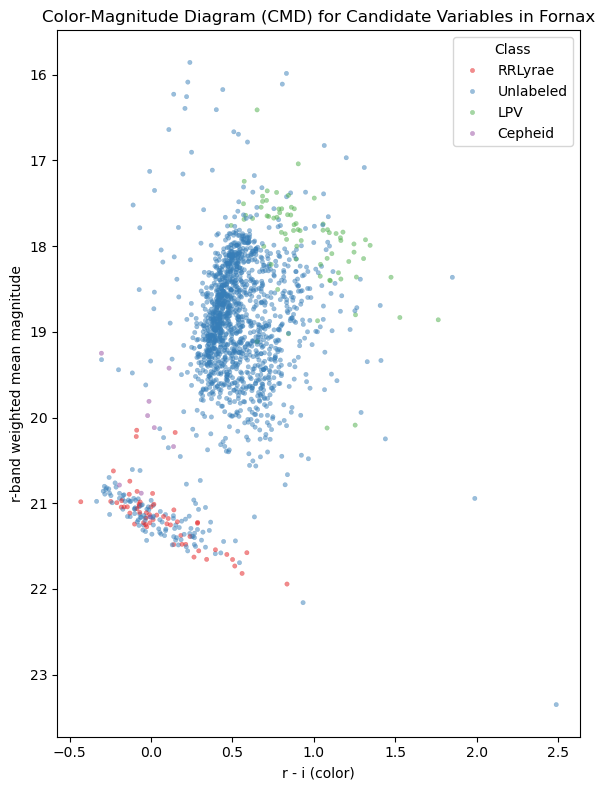

In [54]:
plt.figure(figsize=(6, 8))
sns.scatterplot(
    data=catalog_updated,
    x='r_i',
    y='r_weighted_mean_mag',
    hue='Class',
    palette='Set1',
    alpha=0.5,
    s=10,
    edgecolor=None
)

plt.xlabel('r - i (color)')
plt.ylabel('r-band weighted mean magnitude')
plt.title('Color-Magnitude Diagram (CMD) for Candidate Variables in Fornax')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.legend(title='Class')
plt.show()

### Retrieve Candidate RRLyraes within Color Magnitude Graph (smaller cluster on bottom)

In [56]:
# 'Other' indicates any of those giant stars in the big cluster at the top (potentially LPVs)
catalog_updated['CMD_Class'] = np.where(
    catalog_updated['r_weighted_mean_mag'] > 20.5,
    'Candidate RRL',
    'Other'
)

/tmp/ipykernel_644/3578809597.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catalog_updated['CMD_Class'] = np.where(


In [57]:
catalog_updated.head(10) # check data again to make sure that worked

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red,Class,g_psfFluxMean,i_psfFluxMean,r_psfFluxMean,g_psfFluxErr,i_psfFluxErr,r_psfFluxErr,g_weighted_mean_mag,i_weighted_mean_mag,r_weighted_mean_mag,g_fluxMagMin,i_fluxMagMin,r_fluxMagMin,g_fluxMagMax,i_fluxMagMax,r_fluxMagMax,g_fluxMagPerc05,i_fluxMagPerc05,r_fluxMagPerc05,g_fluxMagPerc95,i_fluxMagPerc95,r_fluxMagPerc95,g_fluxMagMedian,i_fluxMagMedian,r_fluxMagMedian,g_psfFluxMedian,i_psfFluxMedian,r_psfFluxMedian,g_fluxMagMaxSlope,i_fluxMagMaxSlope,r_fluxMagMaxSlope,g_psfFluxSigma,i_psfFluxSigma,r_psfFluxSigma,g_psfFluxMAD,i_psfFluxMAD,r_psfFluxMAD,g_fluxMagSkew,i_fluxMagSkew,r_fluxMagSkew,g_r,r_i,g_i,g_amp,i_amp,r_amp,g_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxSigma_norm,g_psfFluxMAD_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm,CMD_Class
0,604061998853914685,40.027299,-34.799021,15,9.0,6.0,15.697990,9.029769,2393.659912,736.849976,478.731738,92.106277,RRLyrae,15099.034180,11452.456055,10504.007812,178.464005,232.595886,161.432297,20.954910,21.235779,21.228683,20.903637,21.051355,20.940493,20.983316,21.580757,21.733364,20.910539,21.052627,20.959657,20.982251,21.561227,21.719669,20.972658,21.085117,21.608744,14823.000000,13364.500000,8269.824951,166.732401,83.397954,234.964278,607.831649,2520.651528,3533.295166,144.799805,422.099609,809.060303,-1.614498,0.284563,-0.431273,-0.273773,-0.007095,-0.280869,0.071712,0.508600,0.760012,0.040256,0.220097,0.336376,0.009769,0.031584,0.097833,Candidate RRL
1,604062067573391443,40.003437,-34.809701,13,8.0,5.0,13.614340,11.102121,1226.489990,1316.430054,306.622833,188.061454,Unlabeled,7186.423340,11758.537109,13070.529297,157.517334,238.470245,168.748993,21.761461,21.093670,21.068396,21.736628,20.906218,20.812145,21.802395,21.487759,21.514435,21.736806,20.910491,20.895458,21.795997,21.481204,21.506423,21.738413,21.435425,21.085503,7322.080078,9679.214844,13359.850098,158.871968,98.363996,95.987580,245.473749,3160.834011,2446.095518,12.049805,375.469727,855.699707,1.727628,-0.631174,0.943493,0.693066,-0.025274,0.667791,0.059191,0.570714,0.610966,0.034158,0.268812,0.187146,0.001646,0.038791,0.064050,Candidate RRL
2,604062067573391466,39.815931,-34.805787,19,7.0,10.0,32.505468,27.124824,12793.299805,8182.859863,1421.482096,1363.810791,LPV,84036.601562,702449.125000,340613.187500,299.569977,923.109436,577.629700,19.088892,16.783243,17.568020,19.071707,16.719681,17.494127,19.104385,16.816307,17.671936,19.073600,16.731021,17.506402,19.103011,16.814793,17.671316,19.090639,16.789402,17.542982,83896.500000,698616.000000,349005.500000,45.912673,64.534090,173.232058,1271.450650,22614.759225,19813.381089,1055.500000,13924.000000,11513.000000,-0.468850,-1.251037,0.679383,1.520872,0.784777,2.305649,0.029411,0.083772,0.164914,0.015130,0.032194,0.058170,0.012581,0.019931,0.032988,Other
3,604062136292868386,39.689023,-34.802894,9,4.0,5.0,70.929861,40.382877,33659.500000,14270.700195,8414.883789,4756.911458,Unlabeled,72913.796875,136940.000000,134207.796875,273.678986,433.843262,368.506195,19.242973,18.517202,18.537369,19.242973,18.257996,18.280924,19.242973,18.689631,18.860624,19.242973,18.320153,18.282587,19.242973,18.688240,18.853775,19.242973,18.676369,18.816851,72913.796875,122872.500000,107959.000000,NaN,22.504441,82.899550,NaN,29140.827270,38355.935013,0.000000,972.000000,4266.000000,NaN,-1.993332,-0.595549,0.705605,0.020166,0.725771,0.000000,0.368086,0.571188,NaN,0.212800,0.285795,0.000000,0.007911,0.039515,Other
4,604062136292868436,39.721232,-34.822229,9,4.0,5.0,16.132358,11.674339,1624.989990,955.788025,406.248535,318.596090,LPV,NaN,87678.023438,32168.359375,NaN,372.673004,209.688400,NaN,19.041605,20.122463,NaN,18.984514,19.954514,NaN,19.222733,20.264408,NaN,18.985259,19.961888,NaN,19.188210,20.262435,NaN,18.991032,20.236408,NaN,91957.500000,29203.599609,NaN,12.132798,89.257259,NaN,8932.475575,4649.036018,NaN,342.550781,743.500000,NaN,1.

In [58]:
catalog_updated['CMD_Class'].value_counts() 

CMD_Class
Other            1482
Candidate RRL     178
Name: count, dtype: int64

### Feature Engineering and Data Preparation for Unsupervised ML (Clustering)

In [59]:
# retrieve features necessary for discerning different variable types as well as classifications (if known)
features = ['r_weighted_mean_mag', 'i_weighted_mean_mag','i_fluxMagMaxSlope', 'r_fluxMagMaxSlope', 'i_fluxMagSkew', 'r_fluxMagSkew', 'r_i', 'r_amp', 'i_amp',
'i_psfFluxSigma_norm', 'r_psfFluxSigma_norm', 'i_psfFluxMAD_norm', 'r_psfFluxMAD_norm', 'CMD_Class','Class']

In [60]:
catalog_subset = catalog_updated[features]
catalog_subset.isna().sum()

r_weighted_mean_mag    0
i_weighted_mean_mag    0
i_fluxMagMaxSlope      0
r_fluxMagMaxSlope      0
i_fluxMagSkew          1
r_fluxMagSkew          0
r_i                    0
r_amp                  0
i_amp                  0
i_psfFluxSigma_norm    0
r_psfFluxSigma_norm    0
i_psfFluxMAD_norm      0
r_psfFluxMAD_norm      0
CMD_Class              0
Class                  0
dtype: int64

In [61]:
# drop any nulls
catalog_subset = catalog_subset.dropna()

In [62]:
catalog_subset.isna().sum() # check now

r_weighted_mean_mag    0
i_weighted_mean_mag    0
i_fluxMagMaxSlope      0
r_fluxMagMaxSlope      0
i_fluxMagSkew          0
r_fluxMagSkew          0
r_i                    0
r_amp                  0
i_amp                  0
i_psfFluxSigma_norm    0
r_psfFluxSigma_norm    0
i_psfFluxMAD_norm      0
r_psfFluxMAD_norm      0
CMD_Class              0
Class                  0
dtype: int64

In [63]:
catalog_subset

,r_weighted_mean_mag,i_weighted_mean_mag,i_fluxMagMaxSlope,r_fluxMagMaxSlope,i_fluxMagSkew,r_fluxMagSkew,r_i,r_amp,i_amp,i_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm,CMD_Class,Class
0,21.228683,21.235779,83.397954,234.964278,0.284563,-0.431273,-0.007095,0.760012,0.508600,0.220097,0.336376,0.031584,0.097833,Candidate RRL,RRLyrae
1,21.068396,21.093670,98.363996,95.987580,-0.631174,0.943493,-0.025274,0.610966,0.570714,0.268812,0.187146,0.038791,0.064050,Candidate RRL,Unlabeled
2,17.568020,16.783243,64.534090,173.232058,-1.251037,0.679383,0.784777,0.164914,0.083772,0.032194,0.058170,0.019931,0.032988,Other,LPV
3,18.537369,18.517202,22.504441,82.899550,-1.993332,-0.595549,0.020166,0.571188,0.368086,0.212800,0.285795,0.007911,0.039515,Other,Unlabeled
4,20.122463,19.041605,12.132798,89.257259,1.995146,-0.622025,1.080858,0.300547,0.202951,0.101878,0.144522,0.003725,0.025459,Other,LPV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1655,20.979057,21.138042,151.342459,89.689070,-0.565441,1.854468,-0.158985,0.514285,0.433461,0.209837,0.150458,0.056664,0.016590,Candidate RRL,Unlabeled
1656,21.042463,21.059107,159.419962,99.229810,-0.361987,1.467990,-0.016644,0.450027,0.435088,0.189471,0.142624,0.052403,0.032283,Candidate RRL,Unlabeled
1657,18.855709,18.635939,108.845141,390.595598,0.298134,-2.521085,0.219770,0.104405,0.121515,0.043864,0.051165,0.036489,0.021084,Other,Unlabeled
1658,20.842028,21.119312,63.600107,84.489137,-0.001511,1.730150,-0.277285,0.910344,0.631272,0.285608,0.247483,0.268928,0.012694,Candidate RRL,Unlabeled


### Visualize the distributions of each feature to gain intution on which outliers to remove and skewness

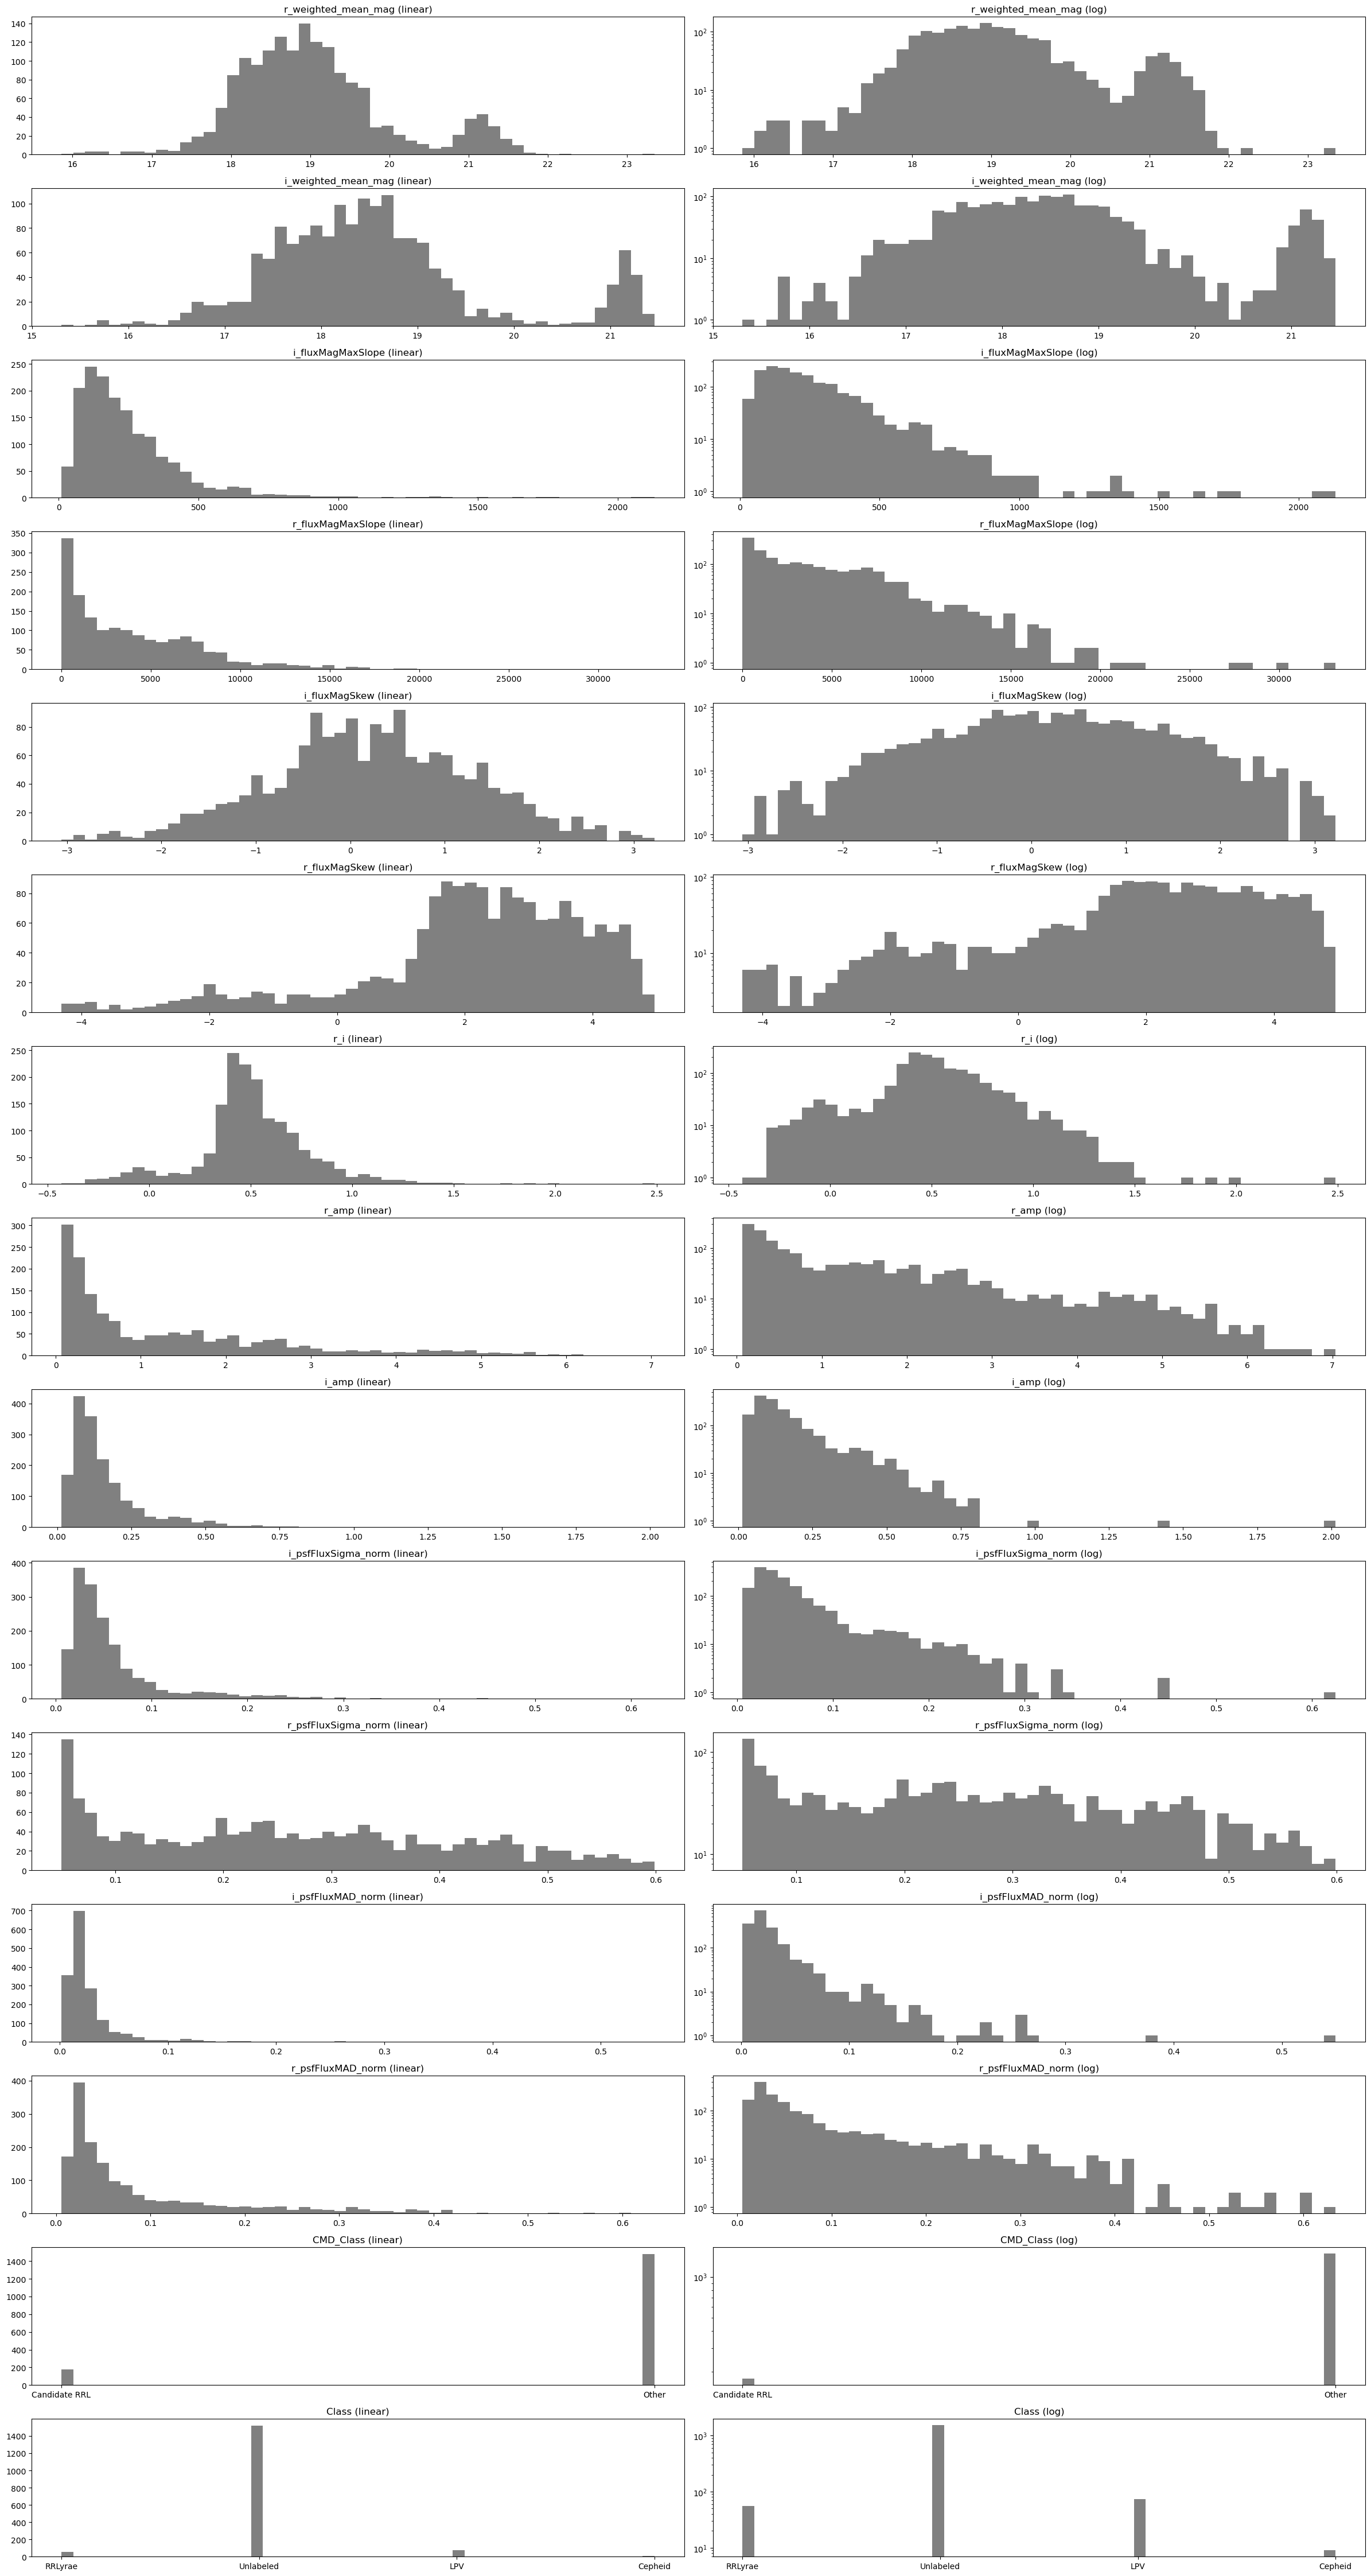

In [65]:
# now that we have all of our helpful features, we can visualize all of them in multiple histograms to see outliers and gain some intuition
# fig = plt.figure(0, [20,18])

# # features.remove('CMD_Class')

# for k, feat in enumerate(features):
#     ax = fig.add_subplot(7, 6, k+1)
#     ax.hist(catalog_subset[feat], bins=50, log=True, color='grey')
#     ax.set_title(feat)
    
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(24, len(features) * 3))  # wide enough for two plots per feature

for k, feat in enumerate(features):
    # Linear scale
    ax1 = fig.add_subplot(len(features), 2, 2*k + 1)
    ax1.hist(catalog_subset[feat], bins=50, color='grey')
    ax1.set_title(f"{feat} (linear)")

    # Log scale
    ax2 = fig.add_subplot(len(features), 2, 2*k + 2)
    ax2.hist(catalog_subset[feat], bins=50, log=True, color='grey')
    ax2.set_title(f"{feat} (log)")

plt.tight_layout()
plt.show()

Based on these results, the features with the most 'skew' are i-band and r-band magnitude max slope, i-amp, and i-band sigma-norm / MAD norm
From here, we will use the IDR-based method for removing extreme outliers in a few of these skewed columns. Additionally, unsure why r_amp has some really extreme values whereas i-band amplitudes are on a much lower scale (still have to investigate into)

### Feature Scaling Using Robust and Standard Scaler

Note: Both of these methods are used for feature scaling however standard scaler transforms data so that each has a mean of 0 and std of 1 whereas robust scaler is more resistant to outliers so it scales according to IQR and Median.

In [183]:
# define X and y
X = catalog_subset.drop(columns=['Class', 'CMD_Class'])
y = catalog_subset['Class']

cmd_class = catalog_subset['CMD_Class']

In [184]:
y.value_counts()

Class
Unlabeled    1521
LPV            73
RRLyrae        56
Cepheid         9
Name: count, dtype: int64

In [185]:
cmd_class.value_counts()

CMD_Class
Other            1481
Candidate RRL     178
Name: count, dtype: int64

In [186]:
# transform each feature to have a mean of 0 and a standard deviation of 1
standard_scaler = StandardScaler()

# alternatively try robust scaler (penalizes outliers more, scaled much higher compared to rest)
robust_scaler = RobustScaler()

X_scaled_std = standard_scaler.fit_transform(X)
X_scaled_rob = robust_scaler.fit_transform(X)

In [187]:
# save each scaled matrix to a df, making sure columns and index are same (important later)
X_scaled_std_df = pd.DataFrame(X_scaled_std, columns=X.columns, index=X.index)
X_scaled_rob_df = pd.DataFrame(X_scaled_rob, columns=X.columns, index=X.index)

In [189]:
X_scaled_std_df

,r_weighted_mean_mag,i_weighted_mean_mag,i_fluxMagMaxSlope,r_fluxMagMaxSlope,i_fluxMagSkew,r_fluxMagSkew,r_i,r_amp,i_amp,i_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm
0,2.208847,2.376749,-0.826717,-0.978402,0.046156,-1.391436,-1.847052,-0.413315,2.508833,2.962789,0.478129,0.117054,0.069716
1,2.045804,2.251043,-0.752406,-1.013702,-0.799510,-0.646662,-1.912205,-0.521815,2.957508,3.856174,-0.515336,0.339319,-0.264831
2,-1.514753,-1.561862,-0.920381,-0.994082,-1.371942,-0.789742,0.991001,-0.846524,-0.559904,-0.483177,-1.373966,-0.242286,-0.572435
3,-0.528739,-0.028041,-1.129071,-1.017026,-2.057438,-1.480431,-1.749347,-0.550772,1.493835,2.828968,0.141399,-0.612954,-0.507799
4,1.083608,0.435833,-1.180569,-1.015411,1.625846,-1.494775,2.052151,-0.747789,0.300987,0.794764,-0.799095,-0.742024,-0.646993
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1655,1.954929,2.290294,-0.489352,-1.015302,-0.738807,-0.153145,-2.391422,-0.592195,1.966067,2.774625,-0.759574,0.890462,-0.734823
1656,2.019426,2.220469,-0.449245,-1.012878,-0.550921,-0.362518,-1.881273,-0.638972,1.977817,2.401142,-0.811729,0.759069,-0.579413
1657,-0.204925,0.076990,-0.700364,-0.938871,0.058688,-2.523582,-1.033970,-0.890573,-0.287265,-0.269155,-1.420600,0.268322,-0.690317
1658,1.815544,2.273725,-0.925019,-1.016622,-0.218028,-0.220494,-2.815405,-0.303879,3.394952,4.164192,-0.113656,7.436061,-0.773406


In [190]:
X_scaled_rob_df

,r_weighted_mean_mag,i_weighted_mean_mag,i_fluxMagMaxSlope,r_fluxMagMaxSlope,i_fluxMagSkew,r_fluxMagSkew,r_i,r_amp,i_amp,i_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm
0,2.134822,2.403332,-0.567944,-0.503817,0.029477,-1.404794,-1.945912,0.012895,3.392616,4.573534,0.340115,0.794487,0.567200
1,1.986298,2.282019,-0.493725,-0.528960,-0.615413,-0.719040,-2.016773,-0.073984,3.932998,5.822390,-0.252802,1.257819,0.198402
2,-1.257191,-1.397643,-0.661494,-0.514985,-1.051939,-0.850782,1.140801,-0.333985,-0.303361,-0.243555,-0.765247,0.045410,-0.140696
3,-0.358981,0.082578,-0.869926,-0.531328,-1.574686,-1.486737,-1.839646,-0.097170,2.170156,4.386466,0.139149,-0.727284,-0.069442
4,1.109786,0.530242,-0.921361,-0.530178,1.234121,-1.499944,2.294925,-0.254925,0.733493,1.542868,-0.422154,-0.996343,-0.222886
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1655,1.903516,2.319898,-0.230996,-0.530099,-0.569122,-0.264631,-2.537977,-0.130338,2.738910,4.310501,-0.398567,2.406729,-0.319708
1656,1.962268,2.252514,-0.190938,-0.528373,-0.425843,-0.457412,-1.983130,-0.167794,2.753062,3.788412,-0.429694,2.132828,-0.148387
1657,-0.064004,0.183939,-0.441747,-0.475661,0.039034,-2.447224,-1.061590,-0.369255,0.025005,0.055625,-0.793079,1.109820,-0.270646
1658,1.776542,2.303909,-0.666125,-0.531040,-0.171985,-0.326643,-2.999108,0.100523,4.459855,6.252966,-0.013072,16.051651,-0.362242


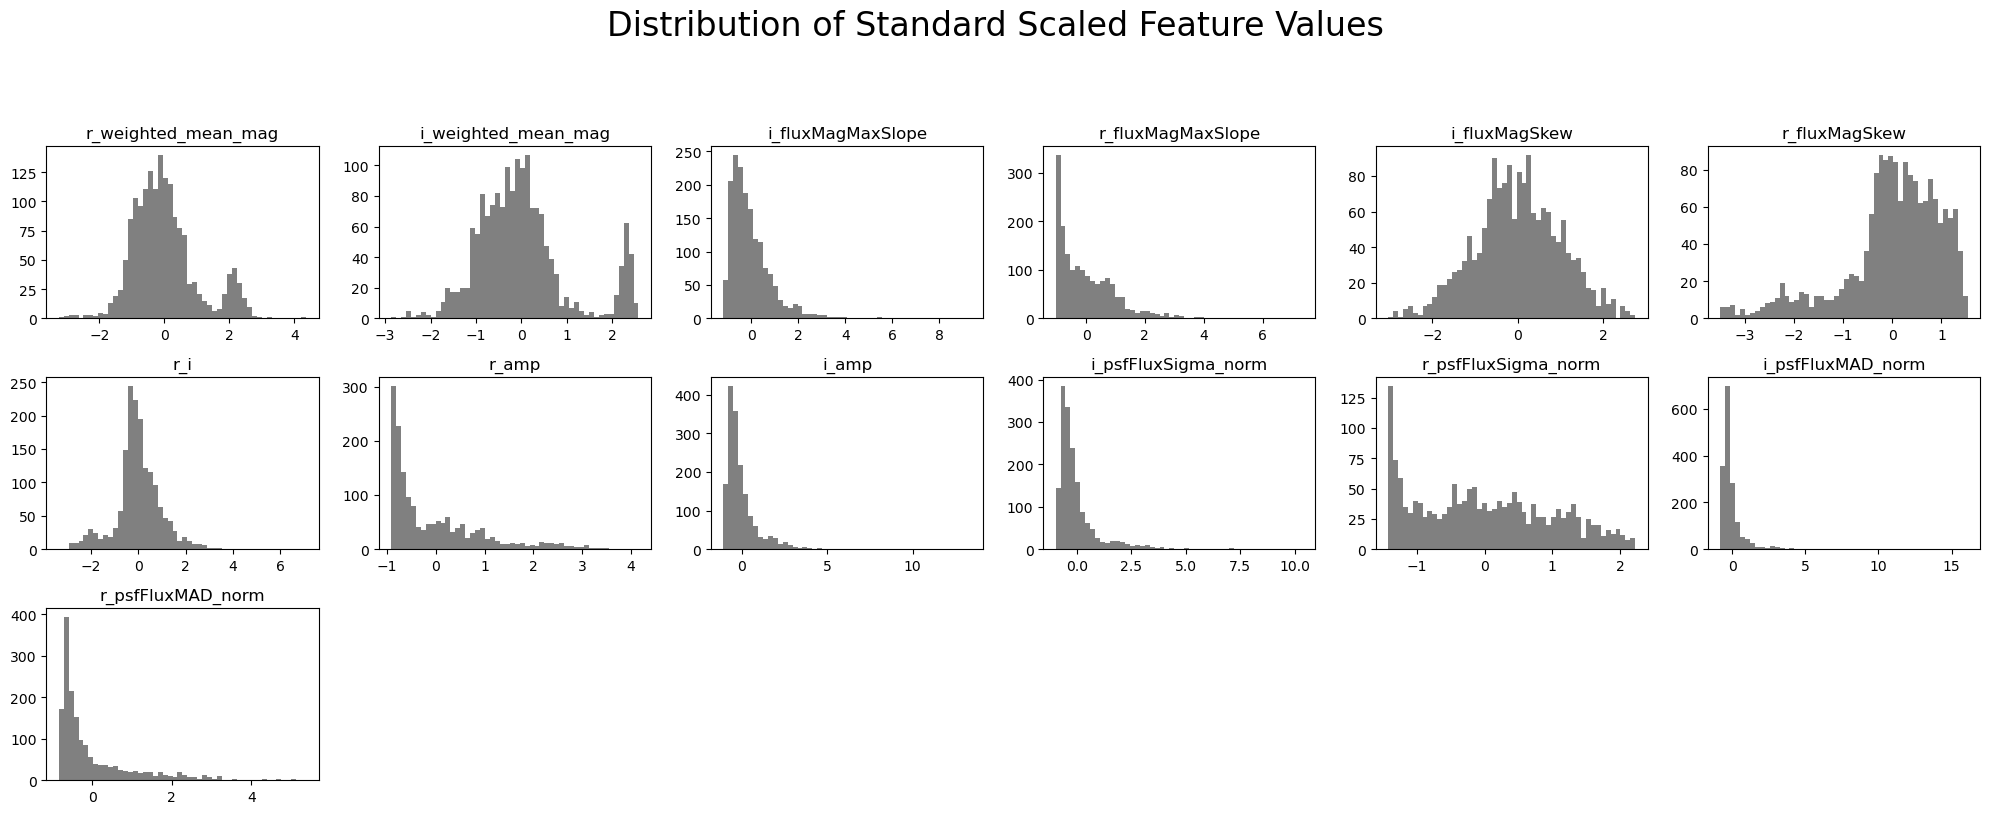

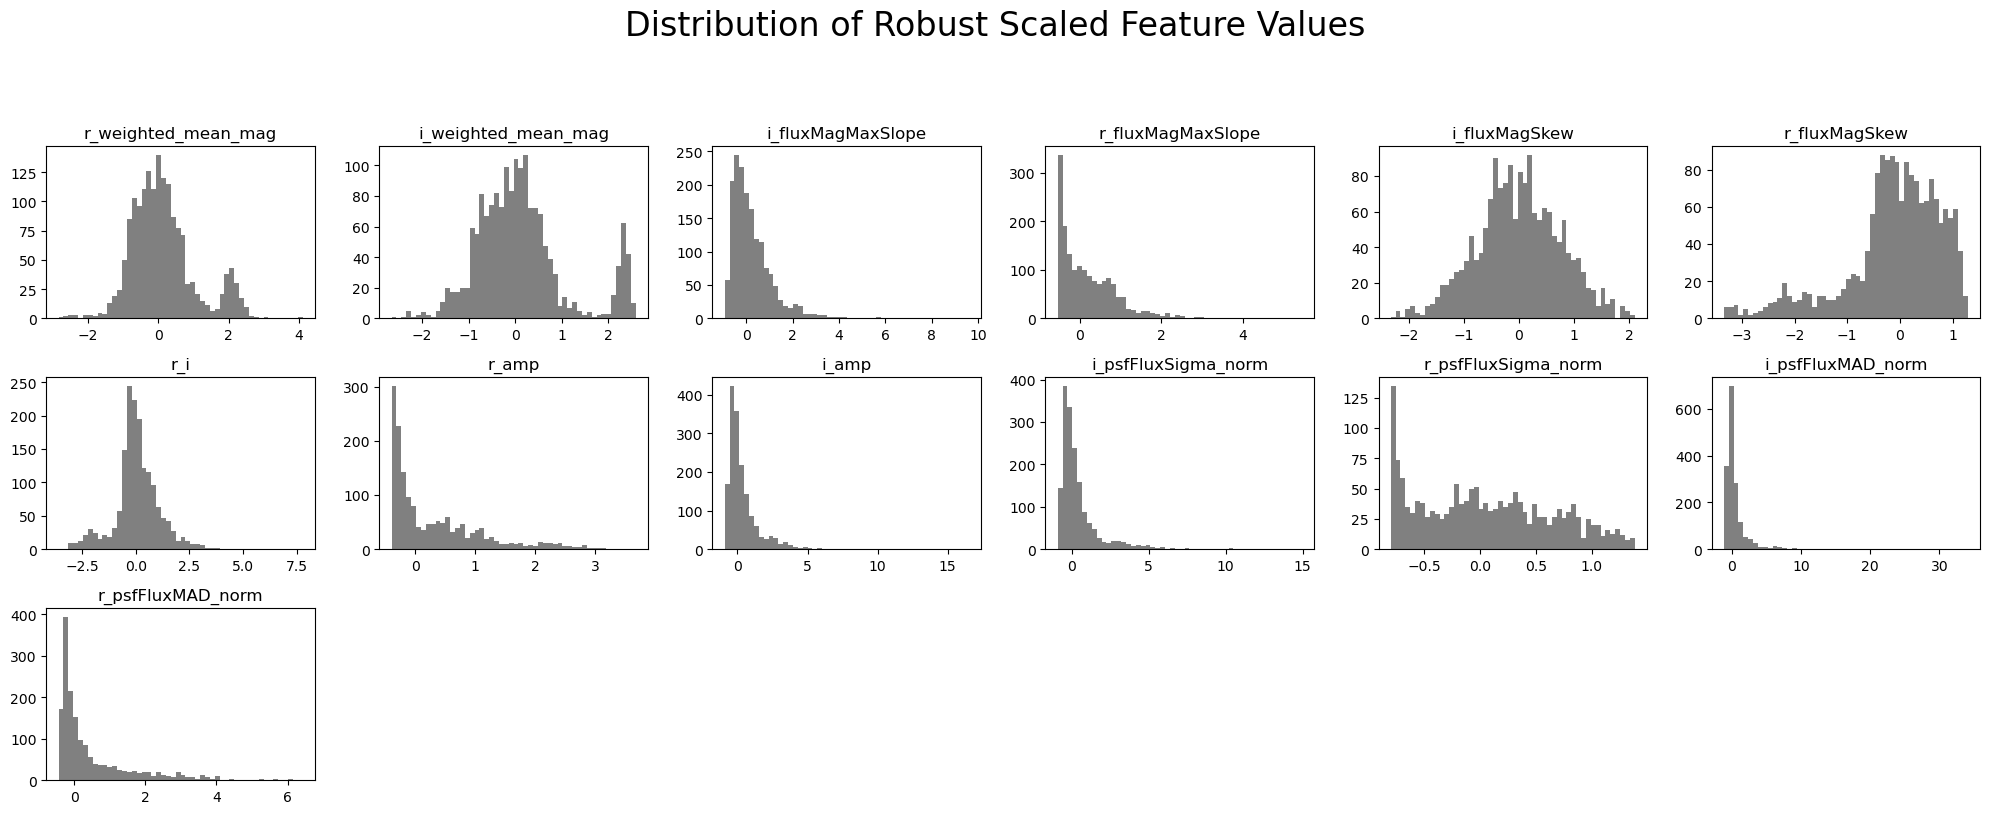

In [191]:
# visualize now
# NOTE: we plotted with non-log scales here just to see how the actual distribution shows
fig = plt.figure(0, [20,18])

for k, feat in enumerate(X_scaled_std_df.columns):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(X_scaled_std_df[feat], bins=50, color='grey')
    ax.set_title(feat)

# Add a title for the entire figure
fig.suptitle("Distribution of Standard Scaled Feature Values", fontsize=24)

# Adjust layout so suptitle doesn't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leaves room for suptitle
plt.show()


# robust scaling
fig = plt.figure(0, [20,18])

for k, feat in enumerate(X_scaled_rob_df.columns):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(X_scaled_rob_df[feat], bins=50, color='grey')
    ax.set_title(feat)

# Add a title for the entire figure
fig.suptitle("Distribution of Robust Scaled Feature Values", fontsize=24)

# Adjust layout so suptitle doesn't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leaves room for suptitle
plt.show()

### Handle and Remove Outliers

In [192]:
def handle_outliers(df, feature, factor=1.5, dropUpper=True, dropLower=True):
    outlier_mask = pd.Series(False, index=df.index)
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    if(dropUpper and dropLower):
        outlier_mask[(df[feature] < lower) | (df[feature] > upper)] = True
    elif dropUpper:
        outlier_mask[df[feature] > upper] = True
    elif dropLower:
        outlier_mask[df[feature] < lower] = True

    return outlier_mask

In [193]:
# we will remove extreme outliers from the max slope columns in both i and r band
outliers_islope = handle_outliers(X_scaled_std_df, 'i_fluxMagMaxSlope', factor=3)
outliers_rslope = handle_outliers(X_scaled_std_df, 'r_fluxMagMaxSlope', factor=3)
outlier_indices = outliers_islope | outliers_rslope

In [194]:
outlier_indices.value_counts()

False    1637
True       22
Name: count, dtype: int64

In [195]:
X_scaled_std_clean = X_scaled_std_df[~outlier_indices]

In [196]:
X_scaled_std_clean.shape

(1637, 13)

In [197]:
X_scaled_std_clean

,r_weighted_mean_mag,i_weighted_mean_mag,i_fluxMagMaxSlope,r_fluxMagMaxSlope,i_fluxMagSkew,r_fluxMagSkew,r_i,r_amp,i_amp,i_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm
0,2.208847,2.376749,-0.826717,-0.978402,0.046156,-1.391436,-1.847052,-0.413315,2.508833,2.962789,0.478129,0.117054,0.069716
1,2.045804,2.251043,-0.752406,-1.013702,-0.799510,-0.646662,-1.912205,-0.521815,2.957508,3.856174,-0.515336,0.339319,-0.264831
2,-1.514753,-1.561862,-0.920381,-0.994082,-1.371942,-0.789742,0.991001,-0.846524,-0.559904,-0.483177,-1.373966,-0.242286,-0.572435
3,-0.528739,-0.028041,-1.129071,-1.017026,-2.057438,-1.480431,-1.749347,-0.550772,1.493835,2.828968,0.141399,-0.612954,-0.507799
4,1.083608,0.435833,-1.180569,-1.015411,1.625846,-1.494775,2.052151,-0.747789,0.300987,0.794764,-0.799095,-0.742024,-0.646993
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1655,1.954929,2.290294,-0.489352,-1.015302,-0.738807,-0.153145,-2.391422,-0.592195,1.966067,2.774625,-0.759574,0.890462,-0.734823
1656,2.019426,2.220469,-0.449245,-1.012878,-0.550921,-0.362518,-1.881273,-0.638972,1.977817,2.401142,-0.811729,0.759069,-0.579413
1657,-0.204925,0.076990,-0.700364,-0.938871,0.058688,-2.523582,-1.033970,-0.890573,-0.287265,-0.269155,-1.420600,0.268322,-0.690317
1658,1.815544,2.273725,-0.925019,-1.016622,-0.218028,-0.220494,-2.815405,-0.303879,3.394952,4.164192,-0.113656,7.436061,-0.773406


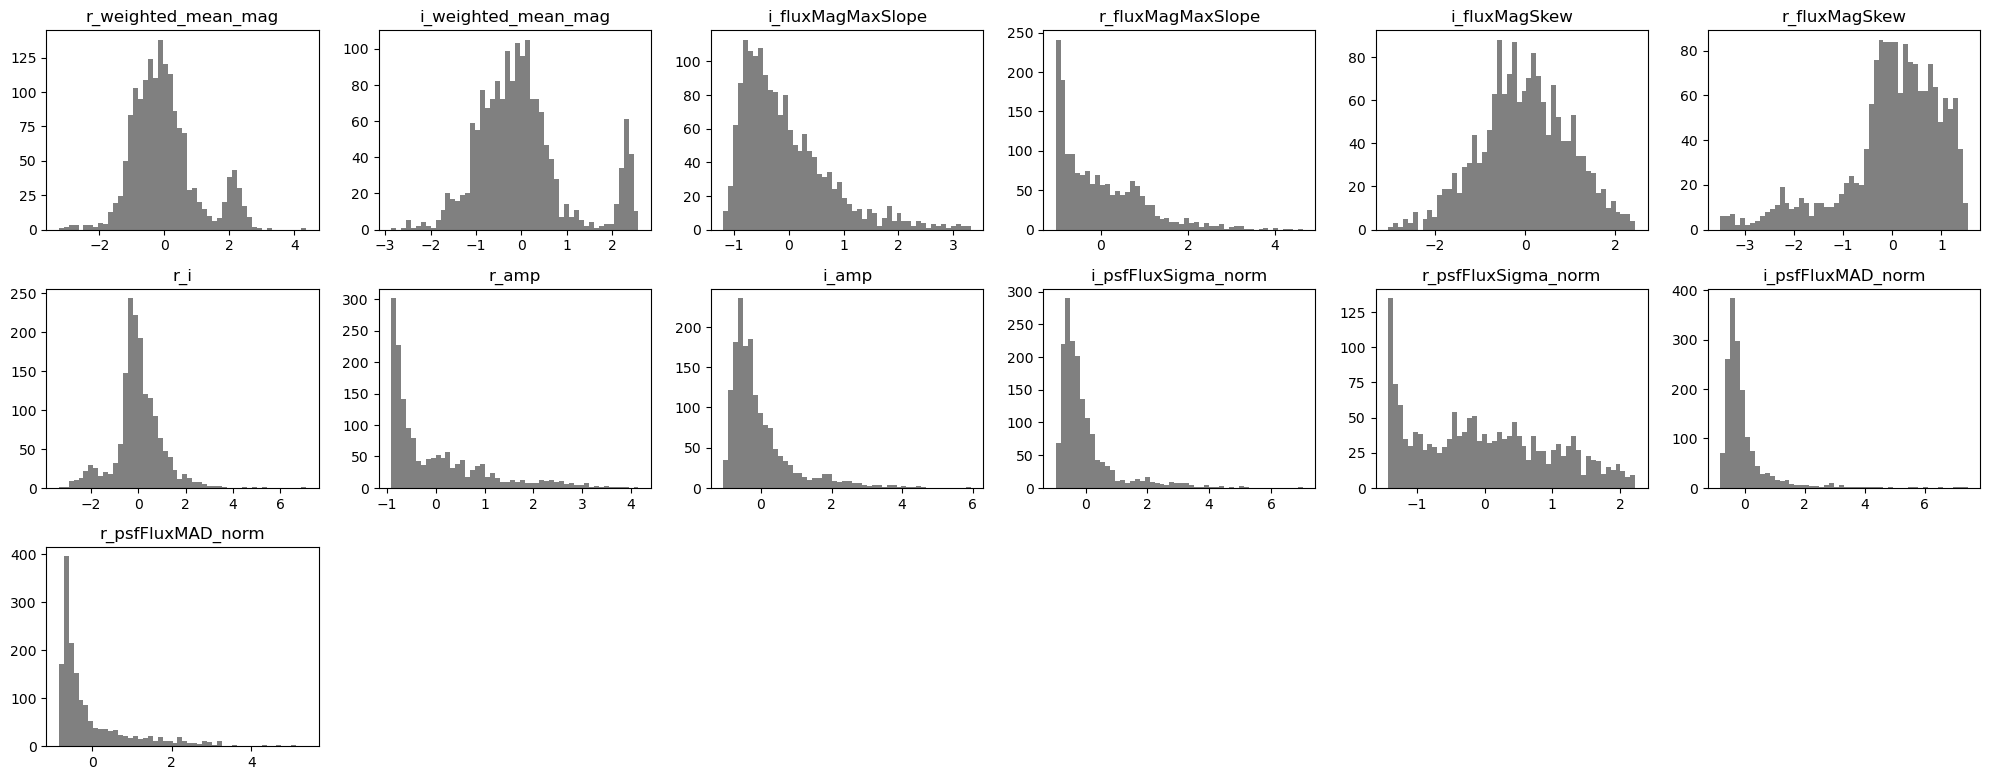

In [198]:
# visualize again after outliers removed
fig = plt.figure(0, [20,18])

for k, feat in enumerate(X_scaled_std_clean.columns):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(X_scaled_std_clean[feat], bins=50, color='grey')
    ax.set_title(feat)
    
plt.tight_layout()
plt.show()

Notice that for the i_fluxMagMaxSlope and r_fluxMagMaxSlope, many of the really extreme outliers were removed (can see from range of values they cover), however there is still lots of skew and this also applies for many of the other features, meaning more columns could be filtered for outliers which is something to experiment with in the future.

In [200]:
# finally let's check the value counts of our 'Class' column after removing outliers
y_cleaned = y.loc[X_scaled_std_clean.index] # get all class values
cmd_class_cleaned = cmd_class.loc[X_scaled_std_clean.index] # get all color magnitude diagram class values

y_cleaned.value_counts()

Class
Unlabeled    1500
LPV            73
RRLyrae        56
Cepheid         8
Name: count, dtype: int64

In [201]:
cmd_class_cleaned.value_counts() # reminder: the true indicates it is a candidate rrlyrae according to the CMD above

CMD_Class
Other            1461
Candidate RRL     176
Name: count, dtype: int64

In [206]:
y_cleaned

0         RRLyrae
1       Unlabeled
2             LPV
3       Unlabeled
4             LPV
          ...    
1655    Unlabeled
1656    Unlabeled
1657    Unlabeled
1658    Unlabeled
1659    Unlabeled
Name: Class, Length: 1637, dtype: object

In [207]:
cmd_class_cleaned

0       Candidate RRL
1       Candidate RRL
2               Other
3               Other
4               Other
            ...      
1655    Candidate RRL
1656    Candidate RRL
1657            Other
1658    Candidate RRL
1659    Candidate RRL
Name: CMD_Class, Length: 1637, dtype: object

**NOTE: We have inferred that lots of the skew and outliers we have in our data is due to much more variablility being captured for the RRLyraes (in a span of 2 days you can get complete periods) contrasted to the little variability captured in lpvs (due to limited observations, variation happening over a long period of time)**

### With data cleaned and outliers removed (to be experimented with), apply dimensionality reduction techniques to visualize the data and look at feature contribution (PCA, t-SNE, UMAP)

In [208]:
# start with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_std_clean)

print(X_pca[:2])

[[ 4.46741766 -2.74926211]
 [ 4.60298361 -3.4620844 ]]


In [209]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.33017896 0.28125757]
Cumulative: [0.33017896 0.61143653]


In [210]:
# encode each of our classes to use for colors in plot
le = LabelEncoder()
y_encoded = le.fit_transform(y_cleaned)

classes = le.classes_
classes

array(['Cepheid', 'LPV', 'RRLyrae', 'Unlabeled'], dtype=object)

In [211]:
# we want to discern the candidate rr lyraes (as indicated in the CMD) through plotting them in a different shape in the visualization
shape_map = {
    'Candidate RRL': '^',
    'Other': 'o'
}

marker_label_map = {
    '^': 'CMD RR Lyrae',
    'o': 'CMD Other'
}

# create a shape map for cmd class
cmd_class_mapped = cmd_class_cleaned.map(shape_map)

In [212]:
cmd_class_mapped.value_counts() # this matches the distribution above

CMD_Class
o    1461
^     176
Name: count, dtype: int64

#### Dim-Red Technique #1: Principal Component Analysis (PCA)

In [213]:
import matplotlib.colors as mcolors

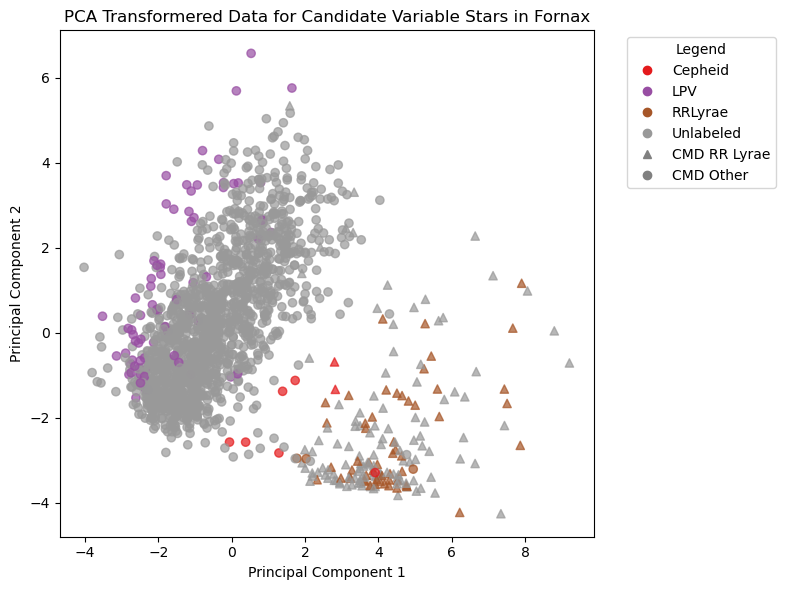

In [214]:
plt.figure(figsize=(8,6))


unique_shapes = set(cmd_class_mapped)

for shape in unique_shapes:
    idx = cmd_class_mapped == shape # retrieve subset based on color mag diagram class (Cand RRL or Other)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=y_encoded[idx], cmap='Set1', marker=shape, alpha=0.7) # plot that subset colored by it's true class
    
cmap = plt.get_cmap('Set1')
norm = mcolors.Normalize(vmin=min(y_encoded), vmax=max(y_encoded))

# adding legend for each class (RRL, Cepheid, LPV, Unlabeled)
color_handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=cmap(norm(i)), label=label)
    for i, label in enumerate(classes)
]

# Add legend for shape corresponding to CMD class (either Cand RRL or Other (likely Red Giants or LPVs))
shape_handles = [
    plt.Line2D([], [], marker=shape, linestyle='', color='gray',
               markerfacecolor='gray', label=marker_label_map[shape])
    for shape in unique_shapes
]

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformered Data for Candidate Variable Stars in Fornax')

plt.legend(handles=color_handles + shape_handles, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**We can see discernible clusters separating our candidate RR Lyraes and other stars (presumably LPVS / Red Giants)! We can ignore the Cepheids since there are so little. Additionally, plotting the color-magnitude labels on top show it to be pretty consistent with those clusters.**

In [215]:
# look at feature weighting / contribution to each component
print(pca.components_) # n_components * n_features (2 x 12)

components_abs = np.abs(pca.components_.T) # now shape is n_features * n_components (can see how much each feature contributes to each PC)
components_norm = components_abs / components_abs.sum(axis=0) # normalize features column wise, so each value shows fractional contributions of feature to that component
# each column should sum up to 1

df_contrib = pd.DataFrame(components_norm, index=X_scaled_std_df.columns, columns=['PC 1', 'PC 2'])
df_contrib

[[ 0.43705636  0.42075026  0.16650883  0.06489779  0.05413843 -0.02470322
  -0.16479943  0.18674032  0.40223491  0.4110317   0.23298904  0.33144135
   0.19890898]
 [-0.12868522 -0.21084344  0.18300268  0.36058694  0.1236058   0.1992014
   0.40085002  0.42665132 -0.07383263 -0.11874878  0.44810853 -0.08265008
   0.38809243]]


,PC 1,PC 2
r_weighted_mean_mag,0.141159,0.040919
i_weighted_mean_mag,0.135892,0.067044
i_fluxMagMaxSlope,0.053778,0.058191
r_fluxMagMaxSlope,0.020960,0.114659
i_fluxMagSkew,0.017485,0.039304
r_fluxMagSkew,0.007979,0.063342
r_i,0.053226,0.127462
r_amp,0.060313,0.135666
i_amp,0.129912,0.023477
i_psfFluxSigma_norm,0.132754,0.037760


Findings: In our PCA, features that contribute to each component (and separating the different classes) the most are apparent magnitude, r-band max slope, r-i color, r and i-band amplitude, as well as normalized standard deviation and MAD in each band. However, outliers in some of those columns might also 'falsely' contribute to captured variability among the components.

### Dim-Red Technique #2 (nonlinear): t-distributed Stochastic Neighbor Embedding (t-SNE)

In [226]:
from sklearn.manifold import TSNE

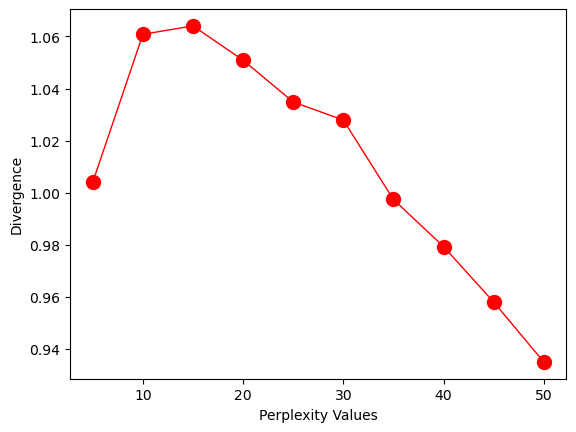

In [227]:
# experiment with hyperparameters (namely divergence)
perplexity = np.arange(5, 55, 5)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i)
    reduced = model.fit_transform(X_scaled_std_clean)
    divergence.append(model.kl_divergence_)
fig = plt.plot(perplexity, divergence, color='red', marker='o', linewidth=1, markersize=10)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")
plt.show()

In [228]:
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X_scaled_std_clean)

In [229]:
# low kl divergence is normally a sign of better results
tsne.kl_divergence_

0.9350322484970093

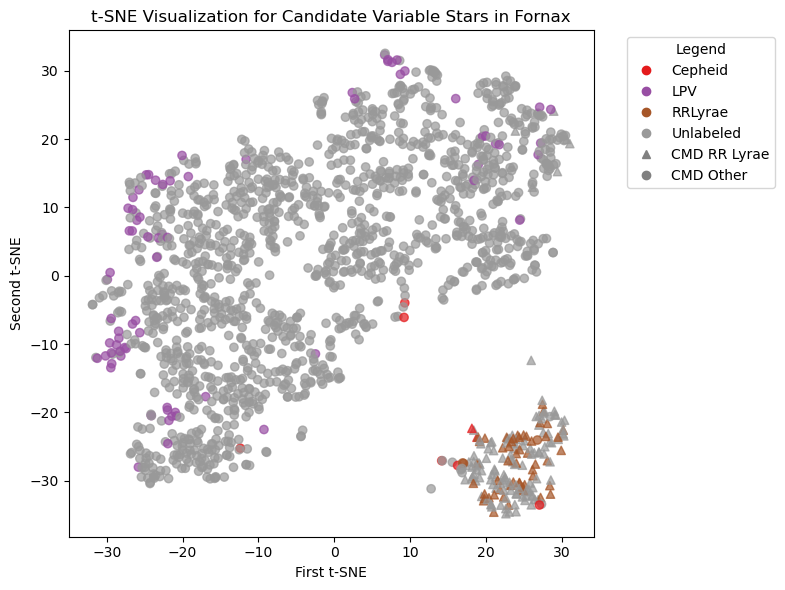

In [233]:
# plot results
plt.figure(figsize=(8,6))

for shape in unique_shapes:
    idx = cmd_class_mapped == shape # retrieve subset based on color mag diagram class (Cand RRL or Other)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], c=y_encoded[idx], cmap='Set1', marker=shape, alpha=0.7) # plot that subset colored by it's true class

# legend for true classes
color_handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=cmap(norm(i)), label=label)
    for i, label in enumerate(classes)
]

# Add legend for shape corresponding to CMD class (either Cand RRL or Other (likely Red Giants or LPVs))
shape_handles = [
    plt.Line2D([], [], marker=shape, linestyle='', color='gray',
               markerfacecolor='gray', label=marker_label_map[shape])
    for shape in unique_shapes
]

plt.xlabel('First t-SNE')
plt.ylabel('Second t-SNE')
plt.title('t-SNE Visualization for Candidate Variable Stars in Fornax')

plt.legend(handles=color_handles + shape_handles, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Dim-Red Technique #3 (nonlinear): Uniform Manifold Approximation and Projection (UMAP)

In [234]:
# necessary imports
import umap
print(umap.__version__)

0.5.9.post2


In [235]:
reducer = umap.UMAP(
    n_neighbors=30, 
    min_dist=0.1, 
    n_components=2, 
    random_state=42)

X_umap = reducer.fit_transform(X_scaled_std_clean)

/home/aadi-bery/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


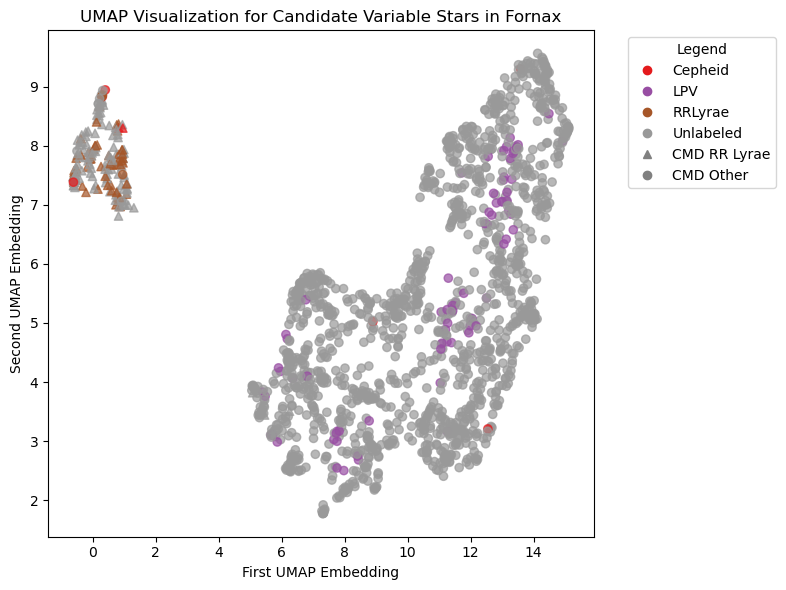

In [236]:
# plot results
plt.figure(figsize=(8,6))

for shape in unique_shapes:
    idx = cmd_class_mapped == shape # retrieve subset based on color mag diagram class (Cand RRL or Other)
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], c=y_encoded[idx], cmap='Set1', marker=shape, alpha=0.7) # plot that subset colored by it's true class

# legend for true classes
color_handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=cmap(norm(i)), label=label)
    for i, label in enumerate(classes)
]

# Add legend for shape corresponding to CMD class (either Cand RRL or Other (likely Red Giants or LPVs))
shape_handles = [
    plt.Line2D([], [], marker=shape, linestyle='', color='gray',
               markerfacecolor='gray', label=marker_label_map[shape])
    for shape in unique_shapes
]

plt.xlabel('First UMAP Embedding')
plt.ylabel('Second UMAP Embedding')
plt.title('UMAP Visualization for Candidate Variable Stars in Fornax')

plt.legend(handles=color_handles + shape_handles, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**More analysis is needed to interpret what each of these two nonlinear algorithms are doing under the hood. Additionally, there is room for hyperparameter tuning on UMAP**

### Implement and Evaluate Unsupervised Machine Learning Methods for Clustering (GMMs, K-Means)

In [247]:
# grab a subset of features with less noise
features_new = ['r_weighted_mean_mag', 'i_weighted_mean_mag', 'r_fluxMagMaxSlope', 'r_i', 'r_amp', 'i_amp',
'r_psfFluxSigma_norm', 'i_psfFluxSigma_norm', 'r_psfFluxMAD_norm']

x_scaled_sub = X_scaled_std_clean[features_new]

In [248]:
x_scaled_sub

,r_weighted_mean_mag,i_weighted_mean_mag,r_fluxMagMaxSlope,r_i,r_amp,i_amp,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_norm
0,2.208847,2.376749,-0.978402,-1.847052,-0.413315,2.508833,0.478129,2.962789,0.069716
1,2.045804,2.251043,-1.013702,-1.912205,-0.521815,2.957508,-0.515336,3.856174,-0.264831
2,-1.514753,-1.561862,-0.994082,0.991001,-0.846524,-0.559904,-1.373966,-0.483177,-0.572435
3,-0.528739,-0.028041,-1.017026,-1.749347,-0.550772,1.493835,0.141399,2.828968,-0.507799
4,1.083608,0.435833,-1.015411,2.052151,-0.747789,0.300987,-0.799095,0.794764,-0.646993
...,...,...,...,...,...,...,...,...,...
1655,1.954929,2.290294,-1.015302,-2.391422,-0.592195,1.966067,-0.759574,2.774625,-0.734823
1656,2.019426,2.220469,-1.012878,-1.881273,-0.638972,1.977817,-0.811729,2.401142,-0.579413
1657,-0.204925,0.076990,-0.938871,-1.033970,-0.890573,-0.287265,-1.420600,-0.269155,-0.690317
1658,1.815544,2.273725,-1.016622,-2.815405,-0.303879,3.394952,-0.113656,4.164192,-0.773406


#### K-Means Clustering

In [249]:
# k-means clustering
kcluster_model = KMeans(n_clusters=2, n_init=20, random_state=42) # 2 clusters for rr lyraes and lpvs / giant stars
# kcluster_model.fit(X_scaled_std_clean)
kcluster_model.fit(x_scaled_sub)

,n_clusters,2
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [250]:
# store labels and transformed centers (for vizualization)
k_labels = kcluster_model.labels_

# centers_pca = pca.transform(kcluster_model.cluster_centers_)
k_labels

array([1, 1, 0, ..., 0, 1, 1], dtype=int32)

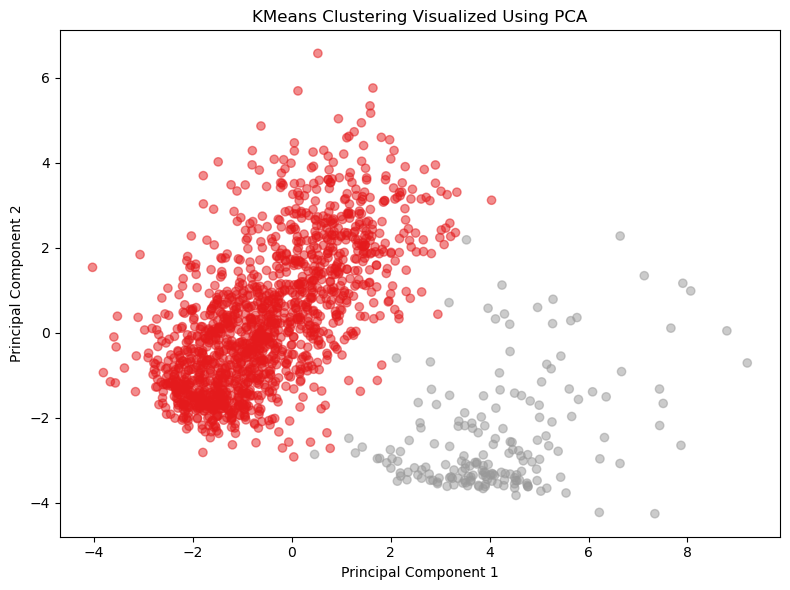

In [251]:
# plot the same pca diagram above but visualize predicted labels from k-means
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=k_labels, cmap='Set1', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# plt.xlim(-5, 15) 
# plt.ylim(-5, 10)

plt.title('KMeans Clustering Visualized Using PCA')
plt.tight_layout()
plt.show()

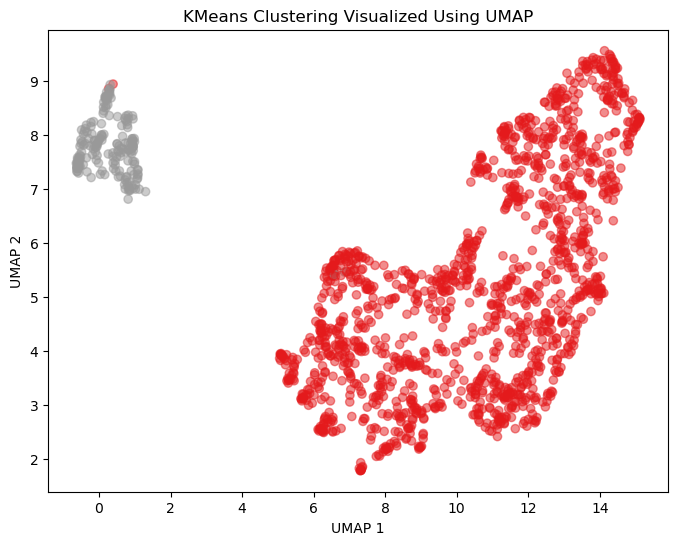

In [252]:
# visualize using UMAP
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=k_labels, cmap='Set1', alpha=0.5)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

plt.title('KMeans Clustering Visualized Using UMAP')
plt.show()

#### Gaussian Mixture Models

In [253]:
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(x_scaled_sub)

gmm_labels = gmm.predict(x_scaled_sub) # grab labels

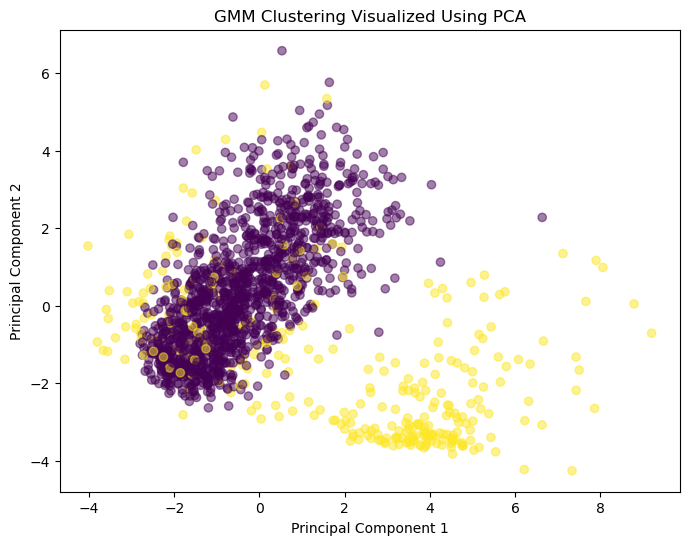

In [254]:
# visualize
# plt.figure(figsize=(10, 6))
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', s=40)
# plt.title('GMM Clustering')
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.colorbar(label='GMM Predictions')
# plt.show()

# # plot true labels as well
# plt.figure(figsize=(10, 6))
# label_colors = {label: cm.rainbow(i / len(classes)) for i, label in enumerate(classes)}
# point_colors = [label_colors[label] for label in y_cleaned]

# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=point_colors, s=40)
# plt.title('Actual Labels')
# plt.xlabel('PCA 1')
# plt.ylabel('PCA 2')

# handles = [
#     plt.Line2D([], [], marker='o', linestyle='', color=label_colors[label], label=label)
#     for label in classes
# ]

# plt.legend(handles=handles, title='Variable Star Type')

# plt.tight_layout()
# plt.show()

# plot the same pca diagram above but visualize predicted labels from gmm
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('GMM Clustering Visualized Using PCA')
plt.show()

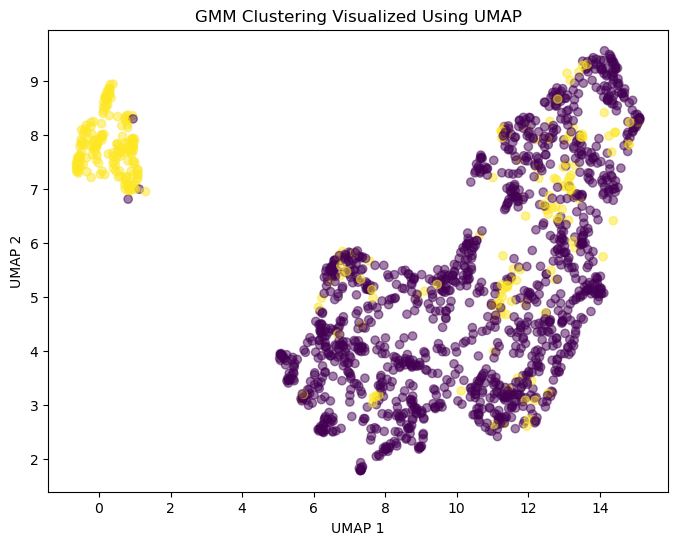

In [329]:
# visualize using UMAP
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=gmm_labels, cmap='viridis', alpha=0.5)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

plt.title('GMM Clustering Visualized Using UMAP')
plt.show()

This is a tad worse from the K-Means clustering and instead puts some of the stars from the 'Red Giant' cluster as part of the RRLyrae Cluster

DBSCAN - just experimentation (need to fix this one)

In [125]:
from sklearn.cluster import DBSCAN

In [131]:
# # Fit DBSCAN (tune eps & min_samples)
# db = DBSCAN(eps=0.75, min_samples=13, n_jobs=-1)
# db.fit(X_scaled_std_clean)
# labels = db.labels_                # -1 = noise
# n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
# n_noise = np.sum(labels == -1)

# print(f"DBSCAN clusters: {n_clusters} | noise points: {n_noise}")

DBSCAN clusters: 2 | noise points: 1507


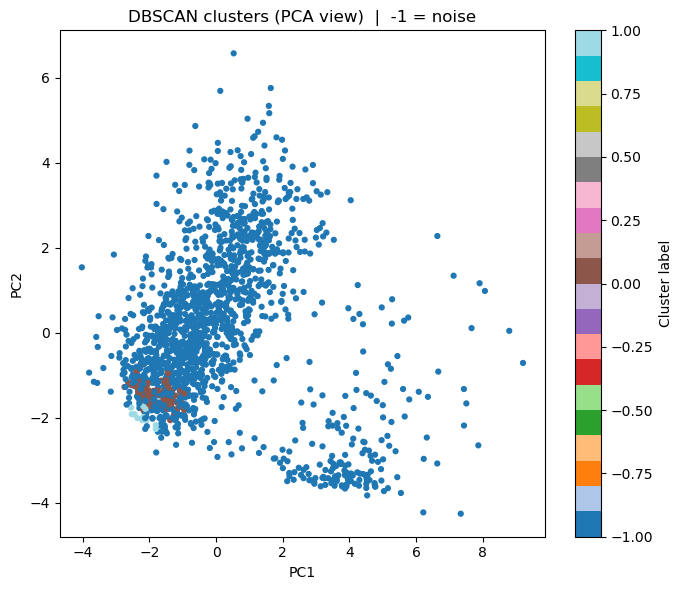

In [132]:
plt.figure(figsize=(7,6))

scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab20', s=12)
plt.title("DBSCAN clusters (PCA view)  |  -1 = noise")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster label")
plt.tight_layout()
plt.show()

### Evaluate Clustering Methods Relative to True Labels

In [258]:
# retrieve predictions from gaussian mixture and kmeans and see accuracy compared to true labels
predictions_df = pd.merge(y_cleaned, cmd_class_cleaned, left_index=True, right_index=True)

predictions_df

,Class,CMD_Class
0,RRLyrae,Candidate RRL
1,Unlabeled,Candidate RRL
2,LPV,Other
3,Unlabeled,Other
4,LPV,Other
...,...,...
1655,Unlabeled,Candidate RRL
1656,Unlabeled,Candidate RRL
1657,Unlabeled,Other
1658,Unlabeled,Candidate RRL


In [259]:
predictions_df['Predictions_KM'] = k_labels
predictions_df['Predictions_KM'].value_counts()

Predictions_KM
0    1453
1     184
Name: count, dtype: int64

In [261]:
print(f'RR Lyraes\n------------\n{predictions_df[predictions_df['Class'] == 'RRLyrae']['Predictions_KM'].value_counts()} \n') # how many of the actual RRL were clustered correctly?
print(f'LPVs\n------------\n{predictions_df[predictions_df['Class'] == 'LPV']['Predictions_KM'].value_counts()} \n')
print(f'Cepheids\n------------\n{predictions_df[predictions_df['Class'] == 'Cepheid']['Predictions_KM'].value_counts()} \n') # we can probably ignore these predictions

RR Lyraes
------------
Predictions_KM
1    56
Name: count, dtype: int64 

LPVs
------------
Predictions_KM
0    73
Name: count, dtype: int64 

Cepheids
------------
Predictions_KM
0    4
1    4
Name: count, dtype: int64 



Looks like all of the classified RRLyraes were predicted to be in cluster 1 and all of the LPVs got clustered in the other which is a good sign. The Cepheids we can ignore since we have so limited of them.

In [262]:
# now evaluate for gmm
predictions_df['Predictions_GMM'] = gmm_labels
predictions_df['Predictions_GMM'].value_counts()

Predictions_GMM
0    1319
1     318
Name: count, dtype: int64

In [263]:
print(f'RR Lyraes\n------------\n{predictions_df[predictions_df['Class'] == 'RRLyrae']['Predictions_GMM'].value_counts()} \n')
print(f'LPVs\n------------\n{predictions_df[predictions_df['Class'] == 'LPV']['Predictions_GMM'].value_counts()} \n')
print(f'Cepheids\n------------\n{predictions_df[predictions_df['Class'] == 'Cepheid']['Predictions_GMM'].value_counts()} \n')

RR Lyraes
------------
Predictions_GMM
1    56
Name: count, dtype: int64 

LPVs
------------
Predictions_GMM
0    38
1    35
Name: count, dtype: int64 

Cepheids
------------
Predictions_GMM
1    7
0    1
Name: count, dtype: int64 



It looks like while the GMMs captured all the labeled RR Lyraes in the same cluster, it looks like it captured a little more noise and a lot more data values closer to LPVs and didn't cluster them as well. There is work to be done on improving this method. On the other hand, the KMeans clustering is a lot more concentrated in the respective clusters so we will go with these predictions for the time being.

### Save Candidate RR Lyraes into DataFrame for Further Analysis and Visualization

In [273]:
predictions_df

,Class,CMD_Class,Predictions_KM,Predictions_GMM
0,RRLyrae,Candidate RRL,1,1
1,Unlabeled,Candidate RRL,1,1
2,LPV,Other,0,0
3,Unlabeled,Other,1,1
4,LPV,Other,0,1
...,...,...,...,...
1655,Unlabeled,Candidate RRL,1,1
1656,Unlabeled,Candidate RRL,1,1
1657,Unlabeled,Other,0,0
1658,Unlabeled,Candidate RRL,1,1


In [274]:
rrl_candidates = predictions_df[(predictions_df['Predictions_KM'] == 1) & ((predictions_df['Class'] == 'RRLyrae') | (predictions_df['Class'] == 'Unlabeled'))]

In [287]:
rrl_candidates # size is 180 since we filtered out the 4 cepheids classified into this cluster

,Class,CMD_Class,Predictions_KM,Predictions_GMM
0,RRLyrae,Candidate RRL,1,1
1,Unlabeled,Candidate RRL,1,1
3,Unlabeled,Other,1,1
6,Unlabeled,Candidate RRL,1,1
7,Unlabeled,Candidate RRL,1,1
...,...,...,...,...
1654,Unlabeled,Candidate RRL,1,1
1655,Unlabeled,Candidate RRL,1,1
1656,Unlabeled,Candidate RRL,1,1
1658,Unlabeled,Candidate RRL,1,1


In [292]:
catalog_updated # indexes look like they match fine

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red,Class,g_psfFluxMean,i_psfFluxMean,r_psfFluxMean,g_psfFluxErr,i_psfFluxErr,r_psfFluxErr,g_weighted_mean_mag,i_weighted_mean_mag,r_weighted_mean_mag,g_fluxMagMin,i_fluxMagMin,r_fluxMagMin,g_fluxMagMax,i_fluxMagMax,r_fluxMagMax,g_fluxMagPerc05,i_fluxMagPerc05,r_fluxMagPerc05,g_fluxMagPerc95,i_fluxMagPerc95,r_fluxMagPerc95,g_fluxMagMedian,i_fluxMagMedian,r_fluxMagMedian,g_psfFluxMedian,i_psfFluxMedian,r_psfFluxMedian,g_fluxMagMaxSlope,i_fluxMagMaxSlope,r_fluxMagMaxSlope,g_psfFluxSigma,i_psfFluxSigma,r_psfFluxSigma,g_psfFluxMAD,i_psfFluxMAD,r_psfFluxMAD,g_fluxMagSkew,i_fluxMagSkew,r_fluxMagSkew,g_r,r_i,g_i,g_amp,i_amp,r_amp,g_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxSigma_norm,g_psfFluxMAD_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm,CMD_Class
0,604061998853914685,40.027299,-34.799021,15,9.0,6.0,15.697990,9.029769,2393.659912,736.849976,478.731738,92.106277,RRLyrae,15099.034180,11452.456055,10504.007812,178.464005,232.595886,161.432297,20.954910,21.235779,21.228683,20.903637,21.051355,20.940493,20.983316,21.580757,21.733364,20.910539,21.052627,20.959657,20.982251,21.561227,21.719669,20.972658,21.085117,21.608744,14823.000000,13364.500000,8269.824951,166.732401,83.397954,234.964278,607.831649,2520.651528,3533.295166,144.799805,422.099609,809.060303,-1.614498,0.284563,-0.431273,-0.273773,-0.007095,-0.280869,0.071712,0.508600,0.760012,0.040256,0.220097,0.336376,0.009769,0.031584,0.097833,Candidate RRL
1,604062067573391443,40.003437,-34.809701,13,8.0,5.0,13.614340,11.102121,1226.489990,1316.430054,306.622833,188.061454,Unlabeled,7186.423340,11758.537109,13070.529297,157.517334,238.470245,168.748993,21.761461,21.093670,21.068396,21.736628,20.906218,20.812145,21.802395,21.487759,21.514435,21.736806,20.910491,20.895458,21.795997,21.481204,21.506423,21.738413,21.435425,21.085503,7322.080078,9679.214844,13359.850098,158.871968,98.363996,95.987580,245.473749,3160.834011,2446.095518,12.049805,375.469727,855.699707,1.727628,-0.631174,0.943493,0.693066,-0.025274,0.667791,0.059191,0.570714,0.610966,0.034158,0.268812,0.187146,0.001646,0.038791,0.064050,Candidate RRL
2,604062067573391466,39.815931,-34.805787,19,7.0,10.0,32.505468,27.124824,12793.299805,8182.859863,1421.482096,1363.810791,LPV,84036.601562,702449.125000,340613.187500,299.569977,923.109436,577.629700,19.088892,16.783243,17.568020,19.071707,16.719681,17.494127,19.104385,16.816307,17.671936,19.073600,16.731021,17.506402,19.103011,16.814793,17.671316,19.090639,16.789402,17.542982,83896.500000,698616.000000,349005.500000,45.912673,64.534090,173.232058,1271.450650,22614.759225,19813.381089,1055.500000,13924.000000,11513.000000,-0.468850,-1.251037,0.679383,1.520872,0.784777,2.305649,0.029411,0.083772,0.164914,0.015130,0.032194,0.058170,0.012581,0.019931,0.032988,Other
3,604062136292868386,39.689023,-34.802894,9,4.0,5.0,70.929861,40.382877,33659.500000,14270.700195,8414.883789,4756.911458,Unlabeled,72913.796875,136940.000000,134207.796875,273.678986,433.843262,368.506195,19.242973,18.517202,18.537369,19.242973,18.257996,18.280924,19.242973,18.689631,18.860624,19.242973,18.320153,18.282587,19.242973,18.688240,18.853775,19.242973,18.676369,18.816851,72913.796875,122872.500000,107959.000000,NaN,22.504441,82.899550,NaN,29140.827270,38355.935013,0.000000,972.000000,4266.000000,NaN,-1.993332,-0.595549,0.705605,0.020166,0.725771,0.000000,0.368086,0.571188,NaN,0.212800,0.285795,0.000000,0.007911,0.039515,Other
4,604062136292868436,39.721232,-34.822229,9,4.0,5.0,16.132358,11.674339,1624.989990,955.788025,406.248535,318.596090,LPV,NaN,87678.023438,32168.359375,NaN,372.673004,209.688400,NaN,19.041605,20.122463,NaN,18.984514,19.954514,NaN,19.222733,20.264408,NaN,18.985259,19.961888,NaN,19.188210,20.262435,NaN,18.991032,20.236408,NaN,91957.500000,29203.599609,NaN,12.132798,89.257259,NaN,8932.475575,4649.036018,NaN,342.550781,743.500000,NaN,1.

In [293]:
# test_catalog = catalog_updated.reset_index().drop(columns=['index'])[['diaObjectId', 'ra', 'dec', 'r_psfFluxNdata', 'i_psfFluxNdata', 'Class', 'CMD_Class', 'i_amp', 'r_amp']]
# test_catalog['Predictions'] = predictions_df['Predictions_KM']

# grab all of the other columns from the original dataframe including coordinates
results_catalog = catalog_updated.loc[rrl_candidates.index]


# # drop all the cepheids since we don't need that for the time being
# not_cepheid = test_catalog['Class'] != 'Cepheid'

# test_catalog = test_catalog[not_cepheid]

# lpv_catalog = test_catalog[(test_catalog['Predictions'] == 0) & ((test_catalog['Class'] == 'LPV' ) | (test_catalog['Class'] == 'Unlabeled'))]

In [294]:
results_catalog.shape

(180, 65)

In [295]:
results_catalog

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red,Class,g_psfFluxMean,i_psfFluxMean,r_psfFluxMean,g_psfFluxErr,i_psfFluxErr,r_psfFluxErr,g_weighted_mean_mag,i_weighted_mean_mag,r_weighted_mean_mag,g_fluxMagMin,i_fluxMagMin,r_fluxMagMin,g_fluxMagMax,i_fluxMagMax,r_fluxMagMax,g_fluxMagPerc05,i_fluxMagPerc05,r_fluxMagPerc05,g_fluxMagPerc95,i_fluxMagPerc95,r_fluxMagPerc95,g_fluxMagMedian,i_fluxMagMedian,r_fluxMagMedian,g_psfFluxMedian,i_psfFluxMedian,r_psfFluxMedian,g_fluxMagMaxSlope,i_fluxMagMaxSlope,r_fluxMagMaxSlope,g_psfFluxSigma,i_psfFluxSigma,r_psfFluxSigma,g_psfFluxMAD,i_psfFluxMAD,r_psfFluxMAD,g_fluxMagSkew,i_fluxMagSkew,r_fluxMagSkew,g_r,r_i,g_i,g_amp,i_amp,r_amp,g_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxSigma_norm,g_psfFluxMAD_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm,CMD_Class
0,604061998853914685,40.027299,-34.799021,15,9.0,6.0,15.697990,9.029769,2393.659912,736.849976,478.731738,92.106277,RRLyrae,15099.034180,11452.456055,10504.007812,178.464005,232.595886,161.432297,20.954910,21.235779,21.228683,20.903637,21.051355,20.940493,20.983316,21.580757,21.733364,20.910539,21.052627,20.959657,20.982251,21.561227,21.719669,20.972658,21.085117,21.608744,14823.000000,13364.500000,8269.824951,166.732401,83.397954,234.964278,607.831649,2520.651528,3533.295166,144.799805,422.099609,809.060303,-1.614498,0.284563,-0.431273,-0.273773,-0.007095,-0.280869,0.071712,0.508600,0.760012,0.040256,0.220097,0.336376,0.009769,0.031584,0.097833,Candidate RRL
1,604062067573391443,40.003437,-34.809701,13,8.0,5.0,13.614340,11.102121,1226.489990,1316.430054,306.622833,188.061454,Unlabeled,7186.423340,11758.537109,13070.529297,157.517334,238.470245,168.748993,21.761461,21.093670,21.068396,21.736628,20.906218,20.812145,21.802395,21.487759,21.514435,21.736806,20.910491,20.895458,21.795997,21.481204,21.506423,21.738413,21.435425,21.085503,7322.080078,9679.214844,13359.850098,158.871968,98.363996,95.987580,245.473749,3160.834011,2446.095518,12.049805,375.469727,855.699707,1.727628,-0.631174,0.943493,0.693066,-0.025274,0.667791,0.059191,0.570714,0.610966,0.034158,0.268812,0.187146,0.001646,0.038791,0.064050,Candidate RRL
3,604062136292868386,39.689023,-34.802894,9,4.0,5.0,70.929861,40.382877,33659.500000,14270.700195,8414.883789,4756.911458,Unlabeled,72913.796875,136940.000000,134207.796875,273.678986,433.843262,368.506195,19.242973,18.517202,18.537369,19.242973,18.257996,18.280924,19.242973,18.689631,18.860624,19.242973,18.320153,18.282587,19.242973,18.688240,18.853775,19.242973,18.676369,18.816851,72913.796875,122872.500000,107959.000000,NaN,22.504441,82.899550,NaN,29140.827270,38355.935013,0.000000,972.000000,4266.000000,NaN,-1.993332,-0.595549,0.705605,0.020166,0.725771,0.000000,0.368086,0.571188,NaN,0.212800,0.285795,0.000000,0.007911,0.039515,Other
6,604062617329205256,40.240457,-34.654019,15,7.0,8.0,6.177447,5.156222,516.187012,298.993988,73.740958,49.832306,Unlabeled,9933.602539,13729.822266,14021.923828,154.129501,236.018661,167.131378,21.409477,21.011770,21.024906,21.350515,20.912563,20.865705,21.542995,21.213791,21.193502,21.352486,20.915279,20.949993,21.518934,21.206189,21.186272,21.373119,21.128105,21.027313,10251.050293,12845.700195,14095.299805,466.781928,204.755568,76.449180,788.363768,1634.703108,1056.394612,152.299805,974.799805,462.700195,1.873154,-0.143600,0.537379,0.384571,0.013136,0.397707,0.166447,0.290910,0.236279,0.079363,0.119062,0.075339,0.014857,0.075885,0.032827,Candidate RRL
7,604062686048681990,40.073289,-34.711542,14,7.0,7.0,7.460580,4.204618,1003.510010,304.635010,167.251597,50.772512,Unlabeled,6465.774902,10540.516602,12113.453125,146.967499,231.791428,164.094727,21.874210,21.284779,21.156490,21.821745,21.140514,21.043571,21.935673,21.546410,21.599266,21.823143,21.155060,21.047999,21.931784,21.538137,21.588081,21.870405,21.426535,21.111870,6488.175049,9764.259766,13039.600098,212.586460,383.616430,112.19684

In [298]:
(results_catalog['Class'] == rrl_candidates['Class']).sum()

np.int64(180)

In [300]:
(results_catalog['CMD_Class'] == rrl_candidates['CMD_Class']).sum() # making sure these are the same

np.int64(180)

In [301]:
results_catalog['Class'].value_counts()

Class
Unlabeled    124
RRLyrae       56
Name: count, dtype: int64

In [119]:
# filter by enough observations
candid_rrl_testing = results_catalog[(results_catalog['r_psfFluxNdata'] >= 10) | (results_catalog['i_psfFluxNdata'] >= 10)]

### Plot Map of Candidate RR Lyrae Stars compared to known ones in Fornax

There are a few categories to consider since we did so much filtering:
1. Candidate RR Lyraes (as predicted by our clustering model) -> 124 of them
2. Known RRLyraes that were contained by filters -> 56 of them
3. All classified RRL that we found to be in Fornax through our data retrieval (found in df loaded at very top) -> total 443 of these (2. is included in this)


In [302]:
# retrieve the set of all labeled RRL found in FORNAX from the labeled variable star catalog
fornax_rrl = v_star_catalog[(v_star_catalog['Region'] == 'Fornax') & (v_star_catalog['Class'] == 'RRLyrae')]

In [303]:
fornax_rrl

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
70,604064060438216798,40.048614,-34.300878,NaN,-2995.556396,-291.404877,NaN,4379.322164,2559.634302,NaN,2729.290000,759.81300,NaN,19.245860,8.397476,NaN,4013.410000,2350.680000,NaN,8.0,10.0,18,Fornax,RRLyrae,RR*,True,NaN,1401.618085,2116.860254,NaN,-2740.915649,-816.080444,NaN,-7141.484888,-3233.477466,NaN,-747.574659,-445.035426,NaN,6.760494e+05,8.785459e+05,NaN,-0.004574,0.029604,NaN,26866.039062,25749.644531,NaN,3437.183396,2830.340765,NaN,20.326991,20.373072,NaN,-0.046081,NaN,NaN,8543.102972,4635.095551,NaN,389.898571,84.423667,NaN,-1.461939,-8.783773,0.221480,NaN,0.135346,NaN,0.127938,0.109918,20.513665,NaN,20.620942,NaN
71,604064747632984333,40.077674,-34.253561,NaN,16426.347656,-1287.950806,NaN,7717.975746,7701.274067,NaN,6090.000000,6136.80000,NaN,18.201519,24.140999,NaN,561.674000,7059.270000,NaN,6.0,10.0,16,Fornax,RRLyrae,RR*,True,NaN,22162.214844,7827.451196,NaN,20375.617188,198.991699,NaN,6477.969604,-7994.327563,NaN,1715.631644,1330.959032,NaN,2.719261e+06,1.859150e+06,NaN,-2.358300,-0.007837,NaN,40820.128906,33034.632812,NaN,7795.080491,7717.890194,NaN,19.872814,20.102576,NaN,-0.229762,NaN,NaN,15684.245239,30156.542407,NaN,1218.000000,681.866667,NaN,0.469853,-5.979478,0.020400,NaN,0.316821,NaN,0.190962,0.233630,20.803581,NaN,21.338467,NaN
72,604064060438217317,40.205677,-34.336792,NaN,3399.735352,125.324951,NaN,1367.813400,1619.171022,NaN,247.874000,192.21600,NaN,3.540597,6.017727,NaN,56.872300,257.084000,NaN,5.0,5.0,10,Fornax,RRLyrae,RR*,True,NaN,4270.294287,1899.028076,NaN,4086.750244,1648.720459,NaN,1671.065625,-1169.555103,NaN,278.533580,269.701942,NaN,6.902030e+05,2.170335e+05,NaN,-2.199190,-0.593852,NaN,16120.375000,12357.556641,NaN,1594.674383,4197.469053,NaN,20.881562,21.170168,NaN,-0.288606,NaN,NaN,2599.228662,5439.849390,NaN,61.968500,48.054000,NaN,0.402329,12.919782,0.005231,NaN,0.030844,NaN,0.098923,0.339668,22.050706,NaN,22.722582,NaN
73,604064060438217129,40.202028,-34.292521,NaN,-3544.424072,206.697922,NaN,4331.009566,3029.584291,NaN,3121.960000,1192.94000,NaN,19.782442,10.944067,NaN,3343.600000,1143.610000,NaN,8.0,11.0,19,Fornax,RRLyrae,RR*,True,NaN,2130.785059,3268.433350,NaN,-4214.549194,-2074.123047,NaN,-7649.482422,-3207.778564,NaN,-712.995455,-524.920705,NaN,1.510586e+06,2.132303e+06,NaN,0.323971,0.210148,NaN,27561.330078,28421.822266,NaN,3767.738035,2954.512501,NaN,20.299250,20.265870,NaN,0.033379,NaN,NaN,9780.267480,5338.563623,NaN,445.994286,119.294000,NaN,-1.221922,14.657062,0.179861,NaN,0.059655,NaN,0.136704,0.103952,20.164030,NaN,20.086323,NaN
74,604063510682403181,39.775055,-34.500566,NaN,-1307.377563,NaN,NaN,89.905096,NaN,NaN,0.754829,NaN,NaN,-0.912004,NaN,NaN,37.747600,NaN,NaN,6.0,NaN,6,Fornax,RRLyrae,RR*,True,NaN,-1182.659943,NaN,NaN,-1331.026489,NaN,NaN,-1398.272949,NaN,NaN,3.944915,NaN,NaN,1.165328e+05,NaN,NaN,1.211190,NaN,NaN,32199.410156,NaN,NaN,3704.773600,NaN,NaN,20.130380,NaN,NaN,NaN,NaN,NaN,215.613

In [304]:
# double check to see that the 56 of the labeled rrl that made it past filters are in here
filtered_fornax_rrl = results_catalog[results_catalog['Class'] == 'RRLyrae']

In [307]:
filtered_fornax_rrl.shape

(56, 65)

In [311]:
filtered_fornax_rrl['diaObjectId'].isin(fornax_rrl['diaObjectId']).all() # looks like they all are 

np.True_

In [312]:
# assign all of the filtered in rrl (56) a boolean of true to differentiate them from the others
fornax_rrl['Filtered In'] = fornax_rrl['diaObjectId'].isin(filtered_fornax_rrl['diaObjectId'])

/tmp/ipykernel_644/351200688.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fornax_rrl['Filtered In'] = fornax_rrl['diaObjectId'].isin(filtered_fornax_rrl['diaObjectId'])


In [314]:
fornax_rrl['Filtered In'].value_counts() # make sure this worked

Filtered In
False    387
True      56
Name: count, dtype: int64

In [315]:
# now retrieve set of candidate rrl from our unsupervised ML modeling
fornax_cand_rrl = results_catalog[results_catalog['Class'] == 'Unlabeled']

In [316]:
fornax_cand_rrl

,diaObjectId,ra,dec,nDiaSources,i_psfFluxNdata,r_psfFluxNdata,r_psfFluxStetsonJ,i_psfFluxStetsonJ,r_psfFluxChi2,i_psfFluxChi2,r_psfFluxChi2_red,i_psfFluxChi2_red,Class,g_psfFluxMean,i_psfFluxMean,r_psfFluxMean,g_psfFluxErr,i_psfFluxErr,r_psfFluxErr,g_weighted_mean_mag,i_weighted_mean_mag,r_weighted_mean_mag,g_fluxMagMin,i_fluxMagMin,r_fluxMagMin,g_fluxMagMax,i_fluxMagMax,r_fluxMagMax,g_fluxMagPerc05,i_fluxMagPerc05,r_fluxMagPerc05,g_fluxMagPerc95,i_fluxMagPerc95,r_fluxMagPerc95,g_fluxMagMedian,i_fluxMagMedian,r_fluxMagMedian,g_psfFluxMedian,i_psfFluxMedian,r_psfFluxMedian,g_fluxMagMaxSlope,i_fluxMagMaxSlope,r_fluxMagMaxSlope,g_psfFluxSigma,i_psfFluxSigma,r_psfFluxSigma,g_psfFluxMAD,i_psfFluxMAD,r_psfFluxMAD,g_fluxMagSkew,i_fluxMagSkew,r_fluxMagSkew,g_r,r_i,g_i,g_amp,i_amp,r_amp,g_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxSigma_norm,g_psfFluxMAD_norm,i_psfFluxMAD_norm,r_psfFluxMAD_norm,CMD_Class
1,604062067573391443,40.003437,-34.809701,13,8.0,5.0,13.614340,11.102121,1226.489990,1316.430054,306.622833,188.061454,Unlabeled,7186.423340,11758.537109,13070.529297,157.517334,238.470245,168.748993,21.761461,21.093670,21.068396,21.736628,20.906218,20.812145,21.802395,21.487759,21.514435,21.736806,20.910491,20.895458,21.795997,21.481204,21.506423,21.738413,21.435425,21.085503,7322.080078,9679.214844,13359.850098,158.871968,98.363996,95.987580,245.473749,3160.834011,2446.095518,12.049805,375.469727,855.699707,1.727628,-0.631174,0.943493,0.693066,-0.025274,0.667791,0.059191,0.570714,0.610966,0.034158,0.268812,0.187146,0.001646,0.038791,0.064050,Candidate RRL
3,604062136292868386,39.689023,-34.802894,9,4.0,5.0,70.929861,40.382877,33659.500000,14270.700195,8414.883789,4756.911458,Unlabeled,72913.796875,136940.000000,134207.796875,273.678986,433.843262,368.506195,19.242973,18.517202,18.537369,19.242973,18.257996,18.280924,19.242973,18.689631,18.860624,19.242973,18.320153,18.282587,19.242973,18.688240,18.853775,19.242973,18.676369,18.816851,72913.796875,122872.500000,107959.000000,NaN,22.504441,82.899550,NaN,29140.827270,38355.935013,0.000000,972.000000,4266.000000,NaN,-1.993332,-0.595549,0.705605,0.020166,0.725771,0.000000,0.368086,0.571188,NaN,0.212800,0.285795,0.000000,0.007911,0.039515,Other
6,604062617329205256,40.240457,-34.654019,15,7.0,8.0,6.177447,5.156222,516.187012,298.993988,73.740958,49.832306,Unlabeled,9933.602539,13729.822266,14021.923828,154.129501,236.018661,167.131378,21.409477,21.011770,21.024906,21.350515,20.912563,20.865705,21.542995,21.213791,21.193502,21.352486,20.915279,20.949993,21.518934,21.206189,21.186272,21.373119,21.128105,21.027313,10251.050293,12845.700195,14095.299805,466.781928,204.755568,76.449180,788.363768,1634.703108,1056.394612,152.299805,974.799805,462.700195,1.873154,-0.143600,0.537379,0.384571,0.013136,0.397707,0.166447,0.290910,0.236279,0.079363,0.119062,0.075339,0.014857,0.075885,0.032827,Candidate RRL
7,604062686048681990,40.073289,-34.711542,14,7.0,7.0,7.460580,4.204618,1003.510010,304.635010,167.251597,50.772512,Unlabeled,6465.774902,10540.516602,12113.453125,146.967499,231.791428,164.094727,21.874210,21.284779,21.156490,21.821745,21.140514,21.043571,21.935673,21.546410,21.599266,21.823143,21.155060,21.047999,21.931784,21.538137,21.588081,21.870405,21.426535,21.111870,6488.175049,9764.259766,13039.600098,212.586460,383.616430,112.196848,336.949745,1560.478988,2027.646243,263.975342,964.834961,362.600586,0.154375,-0.248841,1.303949,0.717720,-0.128288,0.589432,0.108642,0.383076,0.540082,0.052113,0.148046,0.167388,0.040686,0.098813,0.027808,Candidate RRL
14,604062686048682028,40.072549,-34.763345,19,7.0,12.0,3.840134,6.297721,502.329987,292.667999,45.666321,48.778035,Unlabeled,9149.613281,12162.419922,11716.642578,156.555664,227.834915,162.429886,21.496479,21.151392,21.218937,21.406452,21.050467,20.989481,21.558018,21.337471,21.365368,21.418917,21.058838,21.024639,21.555326,21.335649,21.319641,21.531101,21.196987,21.247272,8862.559570,12084.200195,11510.400391,302.285414,148.726270,151.089104,

In [318]:
# check to make sure none of our candidates got accidentally mixed up with labeled stars
fornax_cand_rrl['diaObjectId'].isin(fornax_rrl['diaObjectId']).value_counts()

diaObjectId
False    124
Name: count, dtype: int64

In [109]:
# # get all rrlyraes from our labeled catalog that don't already exist in our filtered rrlyraes (rrl_catalog)
# for index, row in rrl_known.iterrows():
#     if row['diaObjectId'] not in filtered_ids:
#         temp_df = pd.DataFrame([row[['diaObjectId', 'ra', 'dec', 'Class']]])
#         rrl_catalog = pd.concat([rrl_catalog, temp_df])

In [321]:
# edgecolor_map = {
#     'RR Lyrae Filtered In': 'red',
#     'RR Lyrae Filtered Out': 'orange',
#     'Speculated RR Lyrae': 'gray'
# }
facecolor_map = {
    True: 'red',
    False: 'orange',
}
# size_map = {
#     'RR Lyrae Filtered In': 10,
#     'RR Lyrae Filtered Out': 10,
#     'Speculated RR Lyrae': 20
# }

# rrl_catalog['edgecolor'] = rrl_catalog['Class'].map(edgecolor_map)
fornax_rrl['facecolor'] = fornax_rrl['Filtered In'].map(facecolor_map)
# rrl_catalog['size'] = rrl_catalog['Class'].map(size_map)

/tmp/ipykernel_644/1580615650.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fornax_rrl['facecolor'] = fornax_rrl['Filtered In'].map(facecolor_map)


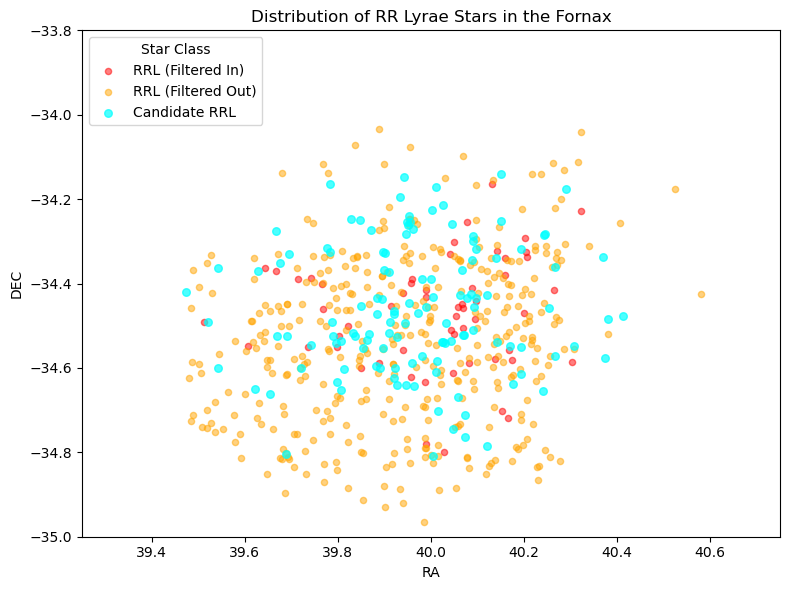

In [328]:
plt.figure(figsize=(8,6))

# --- Plot known/classified RRL (both filtered in & out) ---
plt.scatter(
    fornax_rrl.loc[fornax_rrl['Filtered In'], 'ra'], 
    fornax_rrl.loc[fornax_rrl['Filtered In'], 'dec'], 
    c='red', alpha=0.5, s=20, label="RRL (Filtered In)"
)

plt.scatter(
    fornax_rrl.loc[~fornax_rrl['Filtered In'], 'ra'], 
    fornax_rrl.loc[~fornax_rrl['Filtered In'], 'dec'], 
    c='orange', alpha=0.5, s=20, label="RRL (Filtered Out)"
)

# --- Plot candidate RRLs (from modeling) ---
plt.scatter(
    fornax_cand_rrl['ra'], fornax_cand_rrl['dec'], 
    c='cyan', alpha=0.7, s=30, label="Candidate RRL"
)

plt.xlabel('RA')
plt.ylabel('DEC')
plt.title('Distribution of RR Lyrae Stars in the Fornax')
plt.xlim(39.25, 40.75) # boundaries for right ascension
plt.ylim(-35.0, -33.8) # boundaries for declination
plt.legend(title='Star Class', loc='upper left', frameon=True, facecolor='white')  # Add the legend here

plt.tight_layout()
plt.show()

also look into:
-> Try to take example objects from lpv cluster and look at their lightcurves, compare to labeled ones
    -> lpvs should be pretty linear
-> look into Bersier & Wood and other known v-star sources (from catalog above for fornax specifically, double check if are more)
    -> See position distributions to check for things like crowding issues